# `pyweatherfiles` Tutorial: A Case Study on TMY Generation, EPW Conversion and Climate-Trend Analysis for Seville and Madrid

This notebook is the computational supplementary material for the accompanying manuscript. It reproduces, end to end and using **real, non-synthetic data** for two Spanish provincial capitals (Seville and Madrid), the complete workflow implemented by the **`pyweatherfiles`** package:

1. **Typical Meteorological Year (TMY) generation** -- the Sandia/TMY3 algorithm (`pyweatherfiles.tmy.TMYGenerator`), executed both **step by step** (calling every individual `sandia_step_*` method, together with the full validation and plotting API) and through the **single-call** convenience method `generate_tmy()`, so that both usage styles are demonstrated and cross-checked against each other.
2. **Conversion to EnergyPlus Weather (EPW) format** of the three climate scenarios used in the manuscript's simulation battery: the *historical* multi-year hourly series (`HourlyEPWConverter`), the generated *typical year* (same converter, applied to the TMY output), and the official Spanish *regulatory* reference file in `.met` format (`met_epw_converter.convert_met_to_epw`).
3. **Degree-hours and climate-trend analysis** (`pyweatherfiles.degree_hours`), reproducing the heating/cooling degree-hour indicators and the multi-year trend figure of Section 3.1 of the manuscript, computed here for the two case-study cities.

```{note}
This notebook is intentionally verbose: every call that produces its own output (a printed diagnostic, a table, or a figure) is placed in its own code cell, and every code cell is preceded by a short explanation of the arguments used and their role in the workflow.
```

```{tip}
For the complete technical reference of every class, method and formula used below, see the Sphinx documentation site (when viewed as part of the documentation), or, equivalently, `README.md` / `README_ES.md` in the repository root.
```

## Notebook outline

- **Part 0 -- Setup and input data.** Locate the repository, define the input files of the two case-study cities, and run a pre-flight check of their column names.
- **Part 1 -- Typical Meteorological Year generation.**
  - Part 1.1: Seville, **step by step** (all seven Sandia steps, with the full validation and plotting API).
  - Part 1.2: Seville, **single-call** generation (`generate_tmy()`), cross-checked against the step-by-step result.
  - Part 1.3: Madrid, single-call generation (condensed), demonstrating the same workflow on a second location with a different column layout.
- **Part 2 -- Conversion to EPW format.** The three climate scenarios of the manuscript (historical, typical-year, regulatory), for both cities.
- **Part 3 -- Degree-hours and climate-trend analysis.** Heating/cooling degree-hours, the night-cooling potential, per-city and global (fixed-effects) linear trends, and the resulting trend figure, for Seville and Madrid.
- **Part 4 -- Conclusions and further reading.**

```{note}
Every `validate_*`/`summarize_*` method used below **returns** its result as a `DataFrame` (and stores it in the matching `validation_*` attribute of the generator) instead of dumping a wide table to the console, so the tables in this notebook are rendered as proper tables rather than as fixed-width text. The only deliberate exception is `validate_persistence_selection()`, whose per-month tables are narrow and meant to be read as a sequential report.
```

## Part 0 -- Setup and input data

The two case-study cities are Seville and Madrid -- the same locations used in the manuscript's simulation battery. All of their input files live in `data/`, right next to this notebook (see `docs/source/jupyter_notebooks/` in the repository) so the whole case study is self-contained and version-controlled: the multi-year hourly series (`.xlsx`), the official CTE regulatory reference file (`.met`), and an EPW template used only to supply header metadata (latitude, longitude, elevation, time zone).

| City    | Hourly series (`.xlsx`)                        | Regulatory file (`.met`) | EPW template                  |
|---------|-------------------------------------------------|---------------------------|---------------------------------|
| Seville | `Seville_hourly_data.xlsx`   | `seville.met`           | `ESP_Sevilla.083910_SWEC.epw`    |
| Madrid  | `Madrid_hourly_data.xlsx`    | `madrid.met`            | `ESP_Madrid.082210_IWEC.epw`     |

Seville is treated as the *reference* city, while Madrid is used throughout to demonstrate that the same tools generalise to a second location, potentially with a different column layout in the source file.

In [1]:
import os
import sys

NOTEBOOK_DIR = os.getcwd()


def find_repo_root(start):
    path = os.path.abspath(start)
    while True:
        if os.path.exists(os.path.join(path, 'pyproject.toml')):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError('Could not locate the repository root (pyproject.toml not found).')
        path = parent


REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
sys.path.insert(0, REPO_ROOT)
print('Notebook directory (holds data/ and case_study_output/):', NOTEBOOK_DIR)
print('Repository root (only used to import pyweatherfiles from source):', REPO_ROOT)

Notebook directory (holds data/ and case_study_output/): D:\Python\pyweatherfiles\docs\source\jupyter_notebooks
Repository root (only used to import pyweatherfiles from source): D:\Python\pyweatherfiles


### Input files and output directory

We collect each city's file paths in a small dictionary (`SEVILLE`, `MADRID`) so that every later cell can refer to `SEVILLE['xlsx']`, `SEVILLE['met']`, `SEVILLE['base_epw']`, etc., instead of repeating literal paths. A dedicated scratch folder, `case_study_output/` (created next to this notebook, git-ignored), collects every artefact generated by this notebook (TMY exports, EPW files, degree-hour tables, figures) without touching the tracked input data under `data/`.

In [2]:
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')

SEVILLE = {
    'label': 'Seville',
    'xlsx': os.path.join(DATA_DIR, 'Seville_hourly_data.xlsx'),
    'met': os.path.join(DATA_DIR, 'seville.met'),
    'base_epw': os.path.join(DATA_DIR, 'ESP_Sevilla.083910_SWEC.epw'),
}
MADRID = {
    'label': 'Madrid',
    'xlsx': os.path.join(DATA_DIR, 'Madrid_hourly_data.xlsx'),
    'met': os.path.join(DATA_DIR, 'madrid.met'),
    'base_epw': os.path.join(DATA_DIR, 'ESP_Madrid.082210_IWEC.epw'),
}
for city in (SEVILLE, MADRID):
    print(f"{city['label']:8s} xlsx={os.path.basename(city['xlsx'])}  "
          f"met={os.path.basename(city['met'])}  base_epw={os.path.basename(city['base_epw'])}")

Seville  xlsx=Seville_hourly_data.xlsx  met=seville.met  base_epw=ESP_Sevilla.083910_SWEC.epw
Madrid   xlsx=Madrid_hourly_data.xlsx  met=madrid.met  base_epw=ESP_Madrid.082210_IWEC.epw


In [3]:
OUT_DIR = os.path.join(NOTEBOOK_DIR, 'case_study_output')
os.makedirs(OUT_DIR, exist_ok=True)
print('Tutorial output folder:', OUT_DIR)

Tutorial output folder: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output


### Pre-flight check of the input columns (`TMYGenerator.check_input_expectations`)

Before instantiating any `TMYGenerator`, it is good practice to verify that the expected variables (`time`, dry-bulb temperature, dew-point temperature, wind speed, global horizontal irradiance, direct normal irradiance) can be found in the source file, under whichever column names it happens to use. `check_input_expectations` is a **`@staticmethod`** -- it is called directly on the class, without creating an instance -- and it prints a ready-to-use `column_mapping` snippet for any variable it cannot find automatically.

In [4]:
from pyweatherfiles import tmy

tmy.TMYGenerator.check_input_expectations(SEVILLE['xlsx'], weighting_method='sandia', data_frequency='hourly')

--- Analyzing 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Seville_hourly_data.xlsx' for sandia method (hourly) ---


Found columns (after mapping): ['time', 'Dry-bulb temperature', 'Dew Point temperature', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'Pressure', 'Global Horizontal Irradiance ', 'Beam Horizontal Irradiance ', 'Diffuse Horizontal Irradiance', 'Beam Normal Irradiance ', 'Total Cloud Cover', 'N', 'Emissivity clear sky', 'Emissivity sky', 'IRh', 'Tsky']

Expected Variables: ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI']
Ref: 'time' column found and format looks valid.

Result: Missing exact matches for: ['T_air', 'T_dew', 'Wind_speed', 'GHI']
You likely need to provide or update a `column_mapping` dictionary.
Example structure:
column_mapping = {
    '<your_file_column_for_T_air>': 'T_air',
    '<your_file_column_for_T_dew>': 'T_dew',
    '<your_file_column_for_Wind_speed>': 'Wind_speed',
    '<your_file_column_for_GHI>': 'GHI',
}


{'found_columns': ['time',
  'Dry-bulb temperature',
  'Dew Point temperature',
  'Relative Humidity',
  'Wind Direction',
  'Wind Speed',
  'Pressure',
  'Global Horizontal Irradiance ',
  'Beam Horizontal Irradiance ',
  'Diffuse Horizontal Irradiance',
  'Beam Normal Irradiance ',
  'Total Cloud Cover',
  'N',
  'Emissivity clear sky',
  'Emissivity sky',
  'IRh',
  'Tsky'],
 'expected_variables': ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'missing_exact': ['T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'time_valid': True}

In [5]:
tmy.TMYGenerator.check_input_expectations(MADRID['xlsx'], weighting_method='sandia', data_frequency='hourly')

--- Analyzing 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_hourly_data.xlsx' for sandia method (hourly) ---
Found columns (after mapping): ['time', 'Dry-bulb temperature', 'Dew Point temperature', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'Pressure', 'Global Horizontal Irradiance ', 'Beam Horizontal Irradiance ', 'Diffuse Horizontal Irradiance', 'Beam Normal Irradiance ', 'Total Cloud Cover', 'N', 'Emissivity clear sky', 'Emissivity sky', 'IRh', 'Tsky']

Expected Variables: ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI']
Ref: 'time' column found and format looks valid.

Result: Missing exact matches for: ['T_air', 'T_dew', 'Wind_speed', 'GHI']
You likely need to provide or update a `column_mapping` dictionary.
Example structure:
column_mapping = {
    '<your_file_column_for_T_air>': 'T_air',
    '<your_file_column_for_T_dew>': 'T_dew',
    '<your_file_column_for_Wind_speed>': 'Wind_speed',
    '<your_file_column_for_GHI>': 'GHI',
}


{'found_columns': ['time',
  'Dry-bulb temperature',
  'Dew Point temperature',
  'Relative Humidity',
  'Wind Direction',
  'Wind Speed',
  'Pressure',
  'Global Horizontal Irradiance ',
  'Beam Horizontal Irradiance ',
  'Diffuse Horizontal Irradiance',
  'Beam Normal Irradiance ',
  'Total Cloud Cover',
  'N',
  'Emissivity clear sky',
  'Emissivity sky',
  'IRh',
  'Tsky'],
 'expected_variables': ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'missing_exact': ['T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'time_valid': True}

## Part 1 -- Typical Meteorological Year generation

`pyweatherfiles.tmy.TMYGenerator` implements the Sandia/TMY3 selection algorithm described in Section 2.2.1 of the manuscript, structured as seven explicit, individually auditable steps:

| Step  | Name                                     | Method                                    |
|-------|-------------------------------------------|---------------------------------------------|
| 1     | Data loading and preparation               | `sandia_step_1_load_and_prepare`             |
| 2     | Finkelstein-Schafer candidate selection    | `sandia_step_2_select_candidates_fs`         |
| 3     | Proximity re-ranking                       | `sandia_step_3_proximity_ranking`            |
| 4-5   | Persistence filtering and final selection  | `sandia_step_4_and_5_apply_persistence`      |
| 6     | Raw TMY assembly                           | `sandia_step_6_assemble_tmy`                  |
| 7     | Junction smoothing                          | `sandia_step_7_smooth_junctions`             |

`generate_tmy()` is a convenience method that simply calls these seven methods in order; calling them individually -- as Part 1.1 does for Seville -- additionally allows inspecting and plotting the intermediate state after every step, which is useful both for teaching purposes and for auditing a specific TMY (the audit trail referred to in Section 2.2.2 of the manuscript).

```{note}
Part 1.1 (Seville) exercises **every** public method of `TMYGenerator` -- all seven `sandia_step_*` methods plus the full `validate_*`/`plot_*` diagnostic API -- as a complete tour of the tool. Part 1.2 repeats the Seville generation with the single-call `generate_tmy()` method and cross-checks that it reproduces the step-by-step result. Part 1.3 applies the single-call method to Madrid only, keeping the notebook a manageable length while still demonstrating the workflow on a second location.
```

### Part 1.1 -- Seville: step-by-step generation

We first instantiate a `TMYGenerator` **without** running any step yet -- the constructor only validates arguments and prepares default weights, it loads nothing. The column-mapping arguments (`datetime_col`, `col_temp`, `col_dew`, `col_wind`, `col_ghi`, `col_dni`) are used to point a the actual column name in the climate data file, since Seville's hourly file was produced by the same data-integration pipeline described in Section 2.1 of the manuscript. `cdf_method='daily'` selects candidate months from daily aggregates (fast; recommended for long, multi-decade records), while `hourly_file_path` points at the same file so that Steps 6-7 (assembly and smoothing) still operate at full hourly resolution. `weighting_method='sandia'` reproduces the original Sandia weighting scheme of Table 2 of the manuscript (as opposed to `'tmy3'`, which redistributes solar weight towards DNI). `save_validation_dfs=True` retains every intermediate validation table for later inspection, and `save_session=False` avoids writing a `.pkl`/`.json` session file for this particular exploratory run (Part 1.2's single-call run keeps the default `save_session=True` instead, for full reproducibility).

In [6]:
seville_step = tmy.TMYGenerator(
    file_path=SEVILLE['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=SEVILLE['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    save_session=False,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


#### Step 1 -- Data loading and preparation (`sandia_step_1_load_and_prepare`)

This step resamples the source series to a strict hourly grid, clips residual negative GHI/DNI/wind-speed values to zero, and computes the daily aggregates required by the weighting scheme (mean/max/min dry-bulb and dew-point temperature, mean/max wind speed, daily GHI sum). It populates `self.df_hourly` and `self.df_daily`, and requires a minimum of five complete years of data.

`validate_step_1_data_loading()` audits that result *before* any statistic is computed, and returns a **coverage table** with one row per loaded frame (`df_hourly`, `df_daily`) answering the three questions Step 1 is responsible for:

- *Is the time grid complete?* `Records` vs. `Expected_Records` between the first and the last timestamp (`Missing_Records` is what the resampling could not fill), plus the remaining `NaN_Values`.
- *Is there enough data?* `Years` available, `Missing_Years` (calendar years absent inside the covered range) and `Interpolated_Years`.
- *Are the values usable?* `Negative_GHI_DNI_Wind`, which Step 1 clips to zero and must therefore be 0 here.

```{warning}
`Interpolated_Years` is the reason this validation is worth running. The resampling in Step 1 rebuilds a strict, gap-free grid and interpolates *every* hole, including a whole absent calendar year -- which is exactly the case of the Seville series used here, where **2020 is missing from the source file** and is silently reconstructed as a linear ramp between 2019 and 2021. The coverage table is the only place where that shows up: `Missing_Years` is `-` (the grid is continuous) while `Interpolated_Years` reports `2020`. Such a year is synthetic data and should be treated as such; in practice its distribution is so far from the long-term one that the Finkelstein-Schafer ranking of Step 2 never selects it, but it is still counted among the candidate years.
```

The full `describe()` tables are not printed (they are far too wide to be read as text): they are stored, transposed to one row per variable, in `validation_step1_hourly_stats` and `validation_step1_daily_stats`. The daily one is shown directly below via `df_daily.describe()`.

In [7]:
seville_step.sandia_step_1_load_and_prepare()

Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Seville_hourly_data.xlsx'...


Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]


Resampling data to hourly frequency and interpolating gaps...


Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Seville_hourly_data.xlsx'...


Resampling hourly data and interpolating gaps...


Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 184080 records.
Real data loaded and prepared.


D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:178: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:182: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


In [8]:
seville_step.df_daily.describe()

,T_air_mean,T_air_max,T_air_min,T_dew_mean,T_dew_max,T_dew_min,Wind_speed_mean,Wind_speed_max,GHI_sum
count,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000
mean,18.733612,24.879384,13.345476,10.612490,13.479264,7.193136,9.991805,21.011255,4970.118614
std,6.987114,8.490771,5.902294,4.516247,4.574285,4.836074,4.618992,7.491315,2509.410443
min,2.186924,4.000000,-5.655615,-11.649570,-9.200000,-16.400000,0.675000,3.600000,0.000000
25%,12.725275,18.000000,8.917245,7.682885,10.100000,4.200000,6.679167,14.800000,3044.184900
50%,18.230608,24.000000,13.200000,10.837228,14.000000,7.500000,9.466667,20.500000,4947.442400
75%,24.618183,32.000000,18.200000,13.887461,17.000000,10.500000,12.633333,25.900000,7270.740575
max,36.008333,45.900000,29.200000,22.130138,26.000000,20.200000,38.904167,59.400000,9144.576200


In [9]:
seville_step.validate_step_1_data_loading()

--- Step 1 validation: data loading and preparation ---
Checks that the prepared dataset is continuous, long enough and free of
impossible values before any Finkelstein-Schafer statistic is computed.



df_hourly: 184,080 records x 16 variables  (2005-01-01 00:00 -> 2025-12-31 23:00)
    time grid   : 0 missing records out of 184,080 expected | 0 NaN values
    calendar    : 21 years | missing inside the covered range: -
    value check : 0 negative GHI/DNI/wind-speed values (Step 1 clips them to 0)

df_daily: 7,670 records x 9 variables  (2005-01-01 00:00 -> 2025-12-31 00:00)
    time grid   : 0 missing records out of 7,670 expected | 0 NaN values
    calendar    : 21 years | missing inside the covered range: -
    value check : 0 negative GHI/DNI/wind-speed values (Step 1 clips them to 0)

Returned: the coverage table above, as a DataFrame (also in 'validation_step1_coverage').
Descriptive statistics (one row per variable) are stored in 'validation_step1_hourly_stats' / 'validation_step1_daily_stats'.


,Variables,Records,Start,End,Expected_Records,Missing_Records,NaN_Values,Years,Missing_Years,Interpolated_Years,Negative_GHI_DNI_Wind
Dataset,,,,,,,,,,,
df_hourly,16,184080,2005-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,184080,0,0,21,-,2020,0
df_daily,9,7670,2005-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,7670,0,0,21,-,2020,0


#### Step 2 -- Finkelstein-Schafer candidate selection (`sandia_step_2_select_candidates_fs`)

For each calendar month, the empirical CDF of every weighted index in each candidate year is compared against the long-term CDF of the same month using the Finkelstein-Schafer statistic (Section 2.2.1 of the manuscript, with the explicit 1/N normalisation). `completeness_threshold` (defaults to `self.missing_data_threshold`, 0.9) excludes month-years with less than 90% of their expected readings before ranking; the five candidates with the lowest weighted FS score are retained per month.

In [10]:
seville_step.sandia_step_2_select_candidates_fs(completeness_threshold=0.9)

Step 2: Calculating FS statistics using 'daily' method...
  Month 1: Selected candidates -> [2018, 2013, 2006, 2021, 2025]


  Month 2: Selected candidates -> [2009, 2015, 2016, 2011, 2013]


  Month 3: Selected candidates -> [2011, 2017, 2009, 2010, 2021]
  Month 4: Selected candidates -> [2016, 2008, 2010, 2015, 2013]


  Month 5: Selected candidates -> [2017, 2005, 2023, 2007, 2012]


  Month 6: Selected candidates -> [2022, 2015, 2014, 2021, 2007]


...

  Month 8: Selected candidates -> [2013, 2011, 2005, 2021, 2017]


  Month 9: Selected candidates -> [2013, 2019, 2023, 2021, 2012]


  Month 10: Selected candidates -> [2016, 2013, 2018, 2023, 2008]


  Month 11: Selected candidates -> [2016, 2005, 2011, 2025, 2023]


  Month 12: Selected candidates -> [2005, 2007, 2012, 2023, 2016]


`validate_full_ranking_for_month` **returns** the complete (all available years, not just the Top-5) FS ranking table for a single calendar month -- one row per year, with the per-variable FS statistic, its weight (Table 2 of the manuscript, also available in `seville_step.weights`) and the resulting weighted contribution -- and stores it in `validation_step2_fs_ranking_by_month[month]`. `validate_fs_calculation` instead reconstructs the full numerical breakdown of the FS statistic for **one** variable/month/year triple, point by point, which is what allows auditing the 1/N-normalised formula. We use January and 2013 (the top proximity-ranked candidate for that month, confirmed below) as the running example throughout Part 1.1.

Each call prints only a short summary; the returned tables are displayed right after it, so they render as proper (scrollable) tables instead of fixed-width text.

In [11]:
full_ranking_jan = seville_step.validate_full_ranking_for_month(month=1)


--- Validation of Full FS Ranking for January ---
Years ranked: 21 | weighted variables: 9 (the weights themselves are available in 'weights')
Best-ranked year: 2018 (Total_W_FS = 0.0380)
Returned: the full ranking table as a DataFrame (also stored in 'validation_step2_fs_ranking_by_month[1]').


In [12]:
full_ranking_jan.head(10)

,Year,FS_T_air_max,Weight_T_air_max,W_FS_T_air_max,FS_T_air_min,Weight_T_air_min,W_FS_T_air_min,FS_T_air_mean,Weight_T_air_mean,W_FS_T_air_mean,...,Weight_Wind_speed_max,W_FS_Wind_speed_max,FS_Wind_speed_mean,Weight_Wind_speed_mean,W_FS_Wind_speed_mean,FS_GHI_sum,Weight_GHI_sum,W_FS_GHI_sum,Total_W_FS,Rank
0,2018,0.035628,0.041667,0.001484,0.048709,0.041667,0.002030,0.034736,0.083333,0.002895,...,0.083333,0.006566,0.041772,0.083333,0.003481,0.020663,0.5,0.010331,0.038000,1
1,2013,0.082949,0.041667,0.003456,0.054259,0.041667,0.002261,0.069273,0.083333,0.005773,...,0.083333,0.004150,0.045042,0.083333,0.003754,0.026015,0.5,0.013007,0.044720,2
2,2006,0.064615,0.041667,0.002692,0.090085,0.041667,0.003754,0.072841,0.083333,0.006070,...,0.083333,0.002742,0.111887,0.083333,0.009324,0.050394,0.5,0.025197,0.063676,3
3,2021,0.100342,0.041667,0.004181,0.135920,0.041667,0.005663,0.180913,0.083333,0.015076,...,0.083333,0.007032,0.115207,0.083333,0.009601,0.044101,0.5,0.022050,0.080672,4
4,2025,0.113523,0.041667,0.004730,0.083098,0.041667,0.003462,0.118577,0.083333,0.009881,...,0.083333,0.010662,0.124573,0.083333,0.010381,0.055845,0.5,0.027922,0.083321,5
5,2024,0.125266,0.041667,0.005219,0.105991,0.041667,0.004416,0.137654,0.083333,0.011471,...,0.083333,0.003659,0.047569,0.083333,0.003964,0.039988,0.5,0.019994,0.084900,6
6,2023,0.090927,0.041667,0.003789,0.054507,0.041667,0.002271,0.055795,0.083333,0.004650,...,0.083333,0.008238,0.112036,0.083333,0.009336,0.087558,0.5,0.043779,0.086187,7
7,2009,0.125613,0.041667,0.005234,0.074278,0.041667,0.003095,0.064516,0.083333,0.005376,...,0.083333,0.004517,0.040038,0.083333,0.003336,0.117784,0.5,0.058892,0.088578,8
8,2011,0.071503,0.041667,0.002979,0.153957,0.041667,0.006415,0.076607,0.083333,0.006384,...,0.083333,0.003171,0.068084,0.083333,0.005674,0.093801,0.5,0.046901,0.094582,9
9,2007,0.183638,0.041667,0.007652,0.119518,0.041667,0.004980,0.080274,0.083333,0.006689,...,0.083333,0.007742,0.199445,0.083333,0.016620,0.070958,0.5,0.035479,0.096983,10


In [13]:
fs_breakdown_example = seville_step.validate_fs_calculation(variable='T_air_mean', month=1, year=2013)


--- Validation of FS Calculation for 'T_air_mean' in January of 2013 ---
Interpolation points compared: 200
Sum of 'Absolute_Difference' (final FS value): 8.9563
Returned: the full point-by-point breakdown as a DataFrame ('Interpolation_Point', 'CDF_Long_Term', 'CDF_Candidate_Year', 'Absolute_Difference').


In [14]:
fs_breakdown_example.head()

,Interpolation_Point,CDF_Long_Term,CDF_Candidate_Year,Absolute_Difference
0,2.186924,0.000768,0.0,0.000768
1,2.262785,0.001591,0.0,0.001591
2,2.338647,0.002332,0.0,0.002332
3,2.414508,0.002544,0.0,0.002544
4,2.490369,0.002755,0.0,0.002755


Two diagnostic plots visualise Step 2: `plot_cdfs` overlays the long-term CDF of every weighted variable for one calendar month against the CDFs of its Top-5 candidate years; `plot_fs_details` zooms into a single variable/month/year triple and shows the before/after-interpolation FS calculation.


Generating CDF visualizations for month 1...


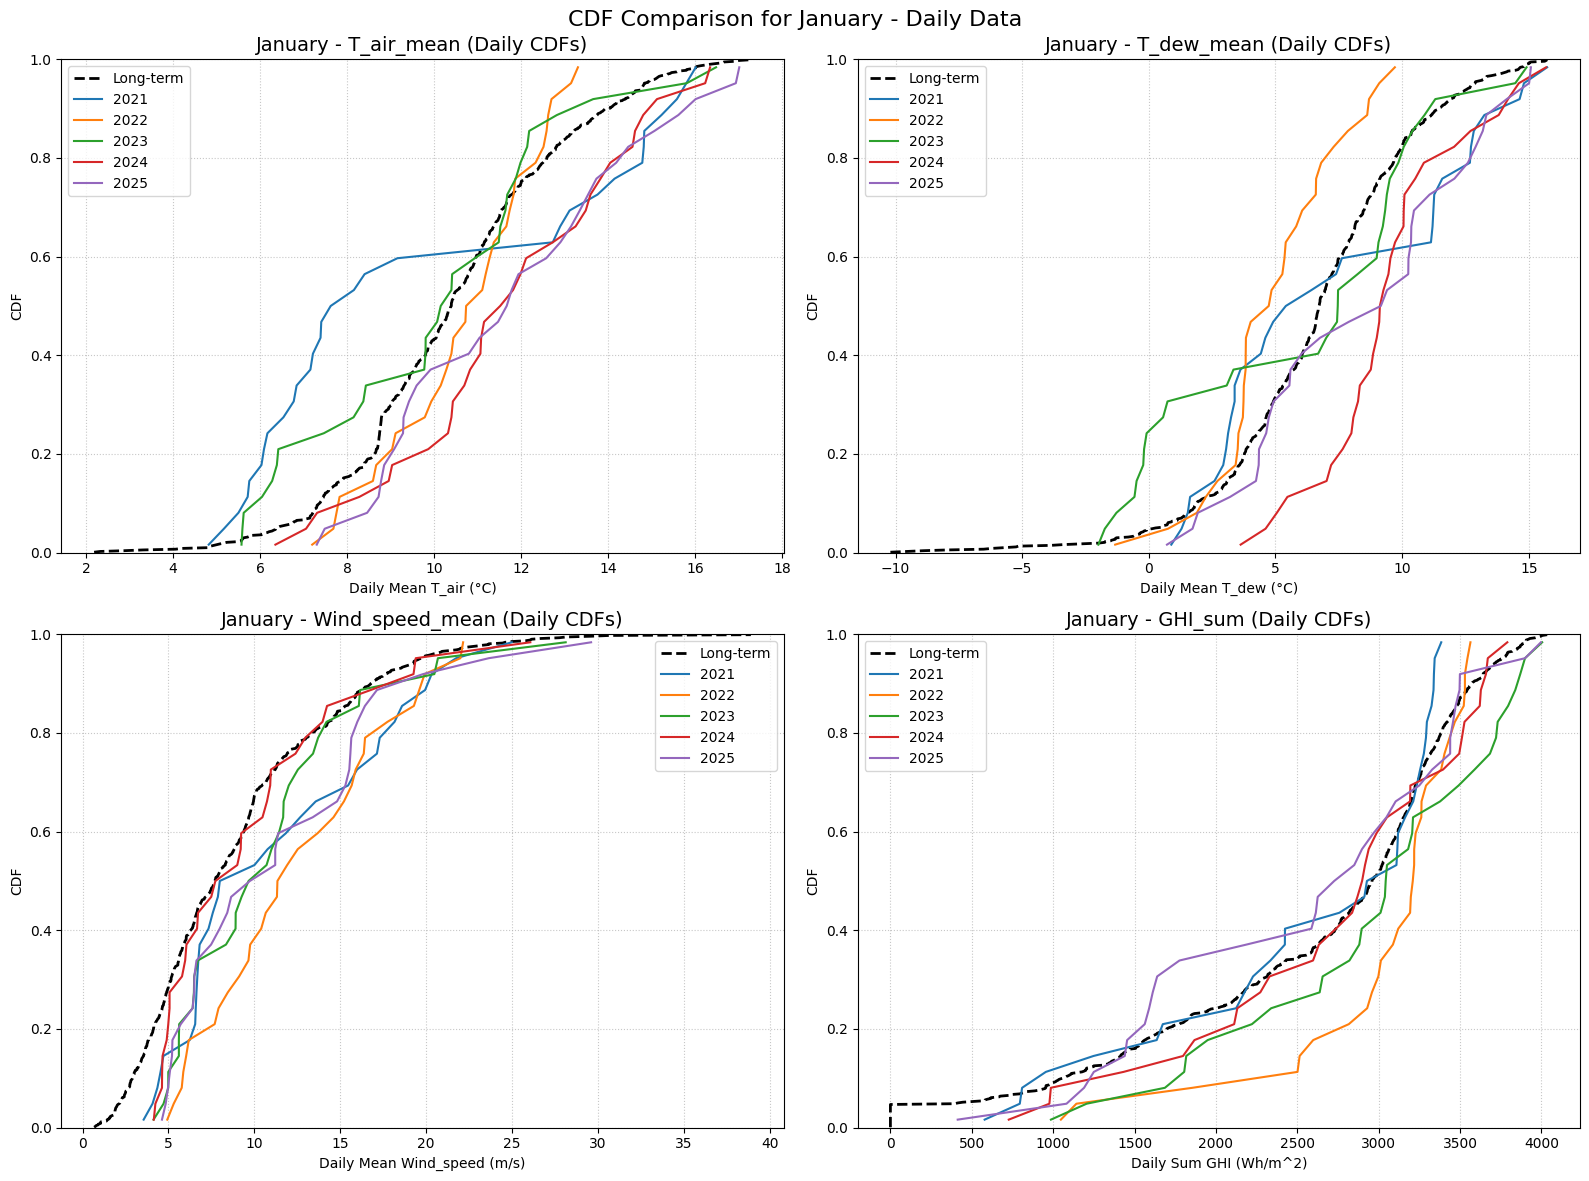

In [15]:
seville_step.plot_cdfs(month_to_plot=1)


Generating FS Statistic visualization for T_air_mean in January 2013...


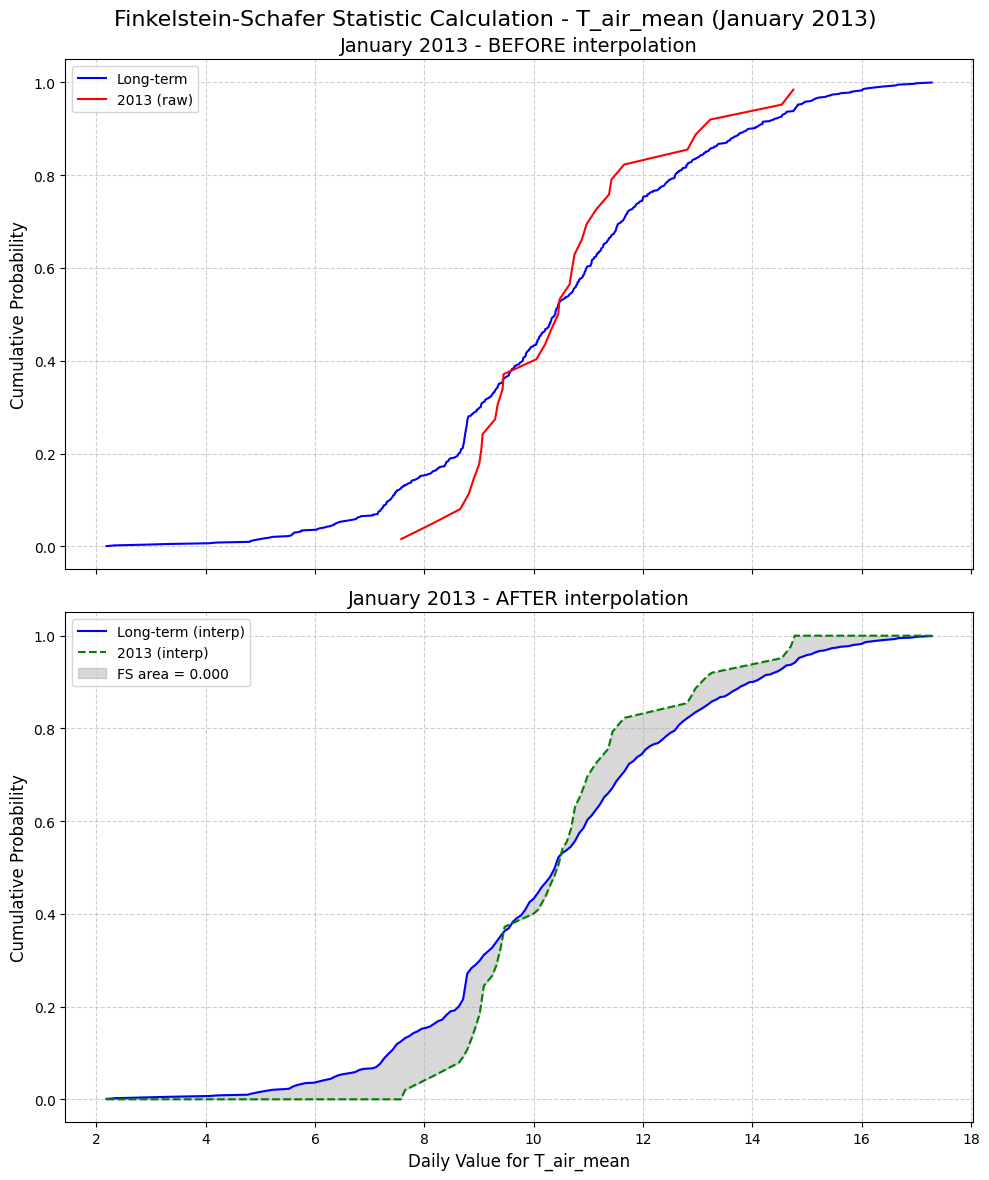

In [16]:
seville_step.plot_fs_details(var_to_plot='T_air_mean', month_to_plot=1, year_to_plot=2013)

#### Step 3 -- Proximity re-ranking (`sandia_step_3_proximity_ranking`)

Following Sawaqed et al. (Section 2.2.1 of the manuscript), the five FS-selected candidates are re-ordered by their closeness to the long-term monthly mean/median of temperature and GHI, normalised according to `normalization_method` (`'std'` here, the manuscript's default; alternatives are `'long_term_mean'`, `'range'`, `'weighted'` and `'no_normalization'`). The result, `self.candidate_months`, is the definitive Top-5 list used by every subsequent step.

In [17]:
seville_step.sandia_step_3_proximity_ranking(normalization_method='std')

Step 3: Applying Proximity Ranking to re-order top 5 candidates (method='std')...
  Month 1: Re-ordered by Proximity -> [2013, 2018, 2006, 2025, 2021]
  Month 2: Re-ordered by Proximity -> [2009, 2011, 2015, 2016, 2013]
  Month 3: Re-ordered by Proximity -> [2017, 2011, 2021, 2010, 2009]
  Month 4: Re-ordered by Proximity -> [2013, 2008, 2015, 2016, 2010]
  Month 5: Re-ordered by Proximity -> [2007, 2023, 2017, 2005, 2012]
  Month 6: Re-ordered by Proximity -> [2021, 2022, 2015, 2007, 2014]
  Month 7: Re-ordered by Proximity -> [2013, 2017, 2008, 2011, 2014]
  Month 8: Re-ordered by Proximity -> [2005, 2021, 2011, 2013, 2017]
  Month 9: Re-ordered by Proximity -> [2023, 2021, 2013, 2012, 2019]
  Month 10: Re-ordered by Proximity -> [2013, 2008, 2018, 2016, 2023]
  Month 11: Re-ordered by Proximity -> [2025, 2005, 2016, 2011, 2023]
  Month 12: Re-ordered by Proximity -> [2007, 2016, 2005, 2012, 2023]


`get_candidate_stats` builds a compact per-candidate table (proximity rank, FS score, monthly mean temperature/GHI and their deviation from the long-term value) for a single calendar month -- note that `Is_Selected` is still `False` for every row at this point, since the final year-per-month selection only happens in Steps 4-5 below. `summarize_fs_results` returns the same Top-5 breakdown for every calendar month at once (also stored in `validation_step3_proximity_ranking`), now that `self.candidate_months` (the proximity-ordered list) is available.

In [18]:
seville_step.get_candidate_stats(month=1)

,Prox_Rank,Year,FS_Score,T_mean,T_diff_vs_LT,T_pctil,GHI_mean,GHI_diff_vs_LT,GHI_pctil,Is_Selected
0,1,2013,0.044720,10.520326,0.052223,57.142857,2679.303448,80.257943,42.857143,False
1,2,2018,0.038000,10.593548,0.125445,61.904762,2650.715110,51.669604,38.095238,False
2,3,2006,0.063676,9.890080,-0.578024,33.333333,2682.847654,83.802149,52.380952,False
3,4,2025,0.083321,11.725941,1.257837,80.952381,2512.590684,-86.454822,33.333333,False
4,5,2021,0.080672,9.731048,-0.737055,23.809524,2541.970277,-57.075228,33.333333,False


In [19]:
seville_step.summarize_fs_results()

Ranking breakdown for the Top-5 candidates of each month: 60 rows. Returned as a DataFrame (also stored in 'validation_step3_proximity_ranking').


Prox_Rank  Max_Error  Proximity_Score Proximity_Method  \
Month     Year                                                           
January   2013          1   0.080215         0.080215              std   
          2018          2   0.153693         0.153693              std   
          2006          3   0.227852         0.227852              std   
          2025          4   0.501895         0.501895              std   
          2021          5   1.092935         1.092935              std   
February  2009          1   0.245940         0.245940              std   
          2011          2   0.338984         0.338984              std   
          2015          3   0.408810         0.408810              std   
          2016          4   0.516607         0.516607              std   
          2013          5   0.649370         0.649370              std   
March     2017          1   0.237371         0.237371              std   
          2011          2   0.256286         0.256286              std   
          2021          3   0.309405         0.309405              std   
          2010          4   0.368201         0.368201              std   
          2009          5   0.885002         0.885002              std   
April     2013          1   0.228919         0.228919              std   
          2008          2   0.251991         0.251991              std   
          2015          3   0.266649         0.266649              std   
          2016          4   0.297765         0.297765              std   
          2010          5   0.406709         0.406709              std   
May       2007          1   0.085803         0.085803              std   
          2023          2   0.176952         0.176952              std   
          2017          3   0.272384         0.272384              std   
          2005          4   0.422687         0.422687              std   
          2012          5   0.699580         0.699580              std   
June      2021          1   0.219836         0.219836              std   
          2022          2   0.258140         0.258140              std   
          2015          3   0.301146         0.301146              std   
          2007          4   0.328307         0.328307              std   
          2014          5   0.392012         0.392012              std   
July      2013          1   0.153756         0.153756              std   
          2017          2   0.201715         0.201715              std   
          2008          3   0.220943         0.220943              std   
          2011          4   0.235030         0.235030              std   
          2014          5   0.592648         0.592648              std   
August    2005          1   0.120283         0.120283              std   
          2021          2   0.144976         0.144976              std   
          2011          3   0.190214         0.190214              std   
          2013          4   0.210073         0.210073              std   
          2017          5   0.377298         0.377298              std   
September 2023          1   0.129027         0.129027              std   
          2021          2   0.136652         0.136652              std   
          2013          3   0.193269         0.193269              std   
          2012          4   0.234052         0.234052              std   
          2019          5   0.290318         0.290318              std   
October   2013          1   0.162949         0.162949              std   
          2008          2   0.186168         0.186168              std   
          2018          3   0.194415         0.194415              std   
          2016          4   0.207551         0.207551              std   
          2023          5   0.460750         0.460750              std   
November  2025          1   0.224011         0.224011              std   
          2005          2   0.238152         0.238152              std   
          2016      

#### Steps 4-5 -- Persistence filtering and final selection (`sandia_step_4_and_5_apply_persistence`)

To avoid selecting months that match the long-term distribution only on average while containing anomalous spells, run statistics are computed for consecutive days above/below the monthly 67th/33rd temperature percentile and below the GHI 33rd percentile. `persistence_method='sequential'` reproduces the three-pass deterministic exclusion procedure of Section 2.2.1 of the manuscript (worst run count, then longest run, tie-broken by proximity rank); the alternative `'score'` method instead applies a single weighted-penalty score. `thresholds=(0.33, 0.67)` and `min_run_length=1` are the method's defaults.

In [20]:
seville_step.sandia_step_4_and_5_apply_persistence(persistence_method='sequential')


Applying persistence criteria (Step 4) and Final Selection (Step 5)...


`validate_persistence_selection` prints the detailed per-month exclusion tables. `plot_persistence_runs` plots the daily temperature/GHI series of a given month for every one of its Top-5 candidate years, with the persistence runs highlighted, directly visualising why a given year was excluded or retained.

In [21]:
seville_step.validate_persistence_selection()


--- Validation for Step 3: Persistence Decisions (Sequential Exclusion) ---

Persistence Table for January:
 Prox_Rank  Year  FS_Score  NumRuns  Max_run                               Decision
         1  2013     0.045       15        5    Excluded Pass 1 (Rule 1c: Max Runs)
         2  2018     0.038       13        5                     SELECTED TMY MONTH
         3  2006     0.064       11        7                                       
         4  2025     0.083       12       11                                       
         5  2021     0.081        8       19 Excluded Pass 2 (Rule 2a: Longest Run)
--> Selected Year: 2018

Persistence Table for February:
 Prox_Rank  Year  FS_Score  NumRuns  Max_run                               Decision
         1  2009     0.070        9        8                     SELECTED TMY MONTH
         2  2011     0.085        8        9                                       
         3  2015     0.079       12        6                                  


--- Visualizing Persistence Runs for T_air and GHI in January ---


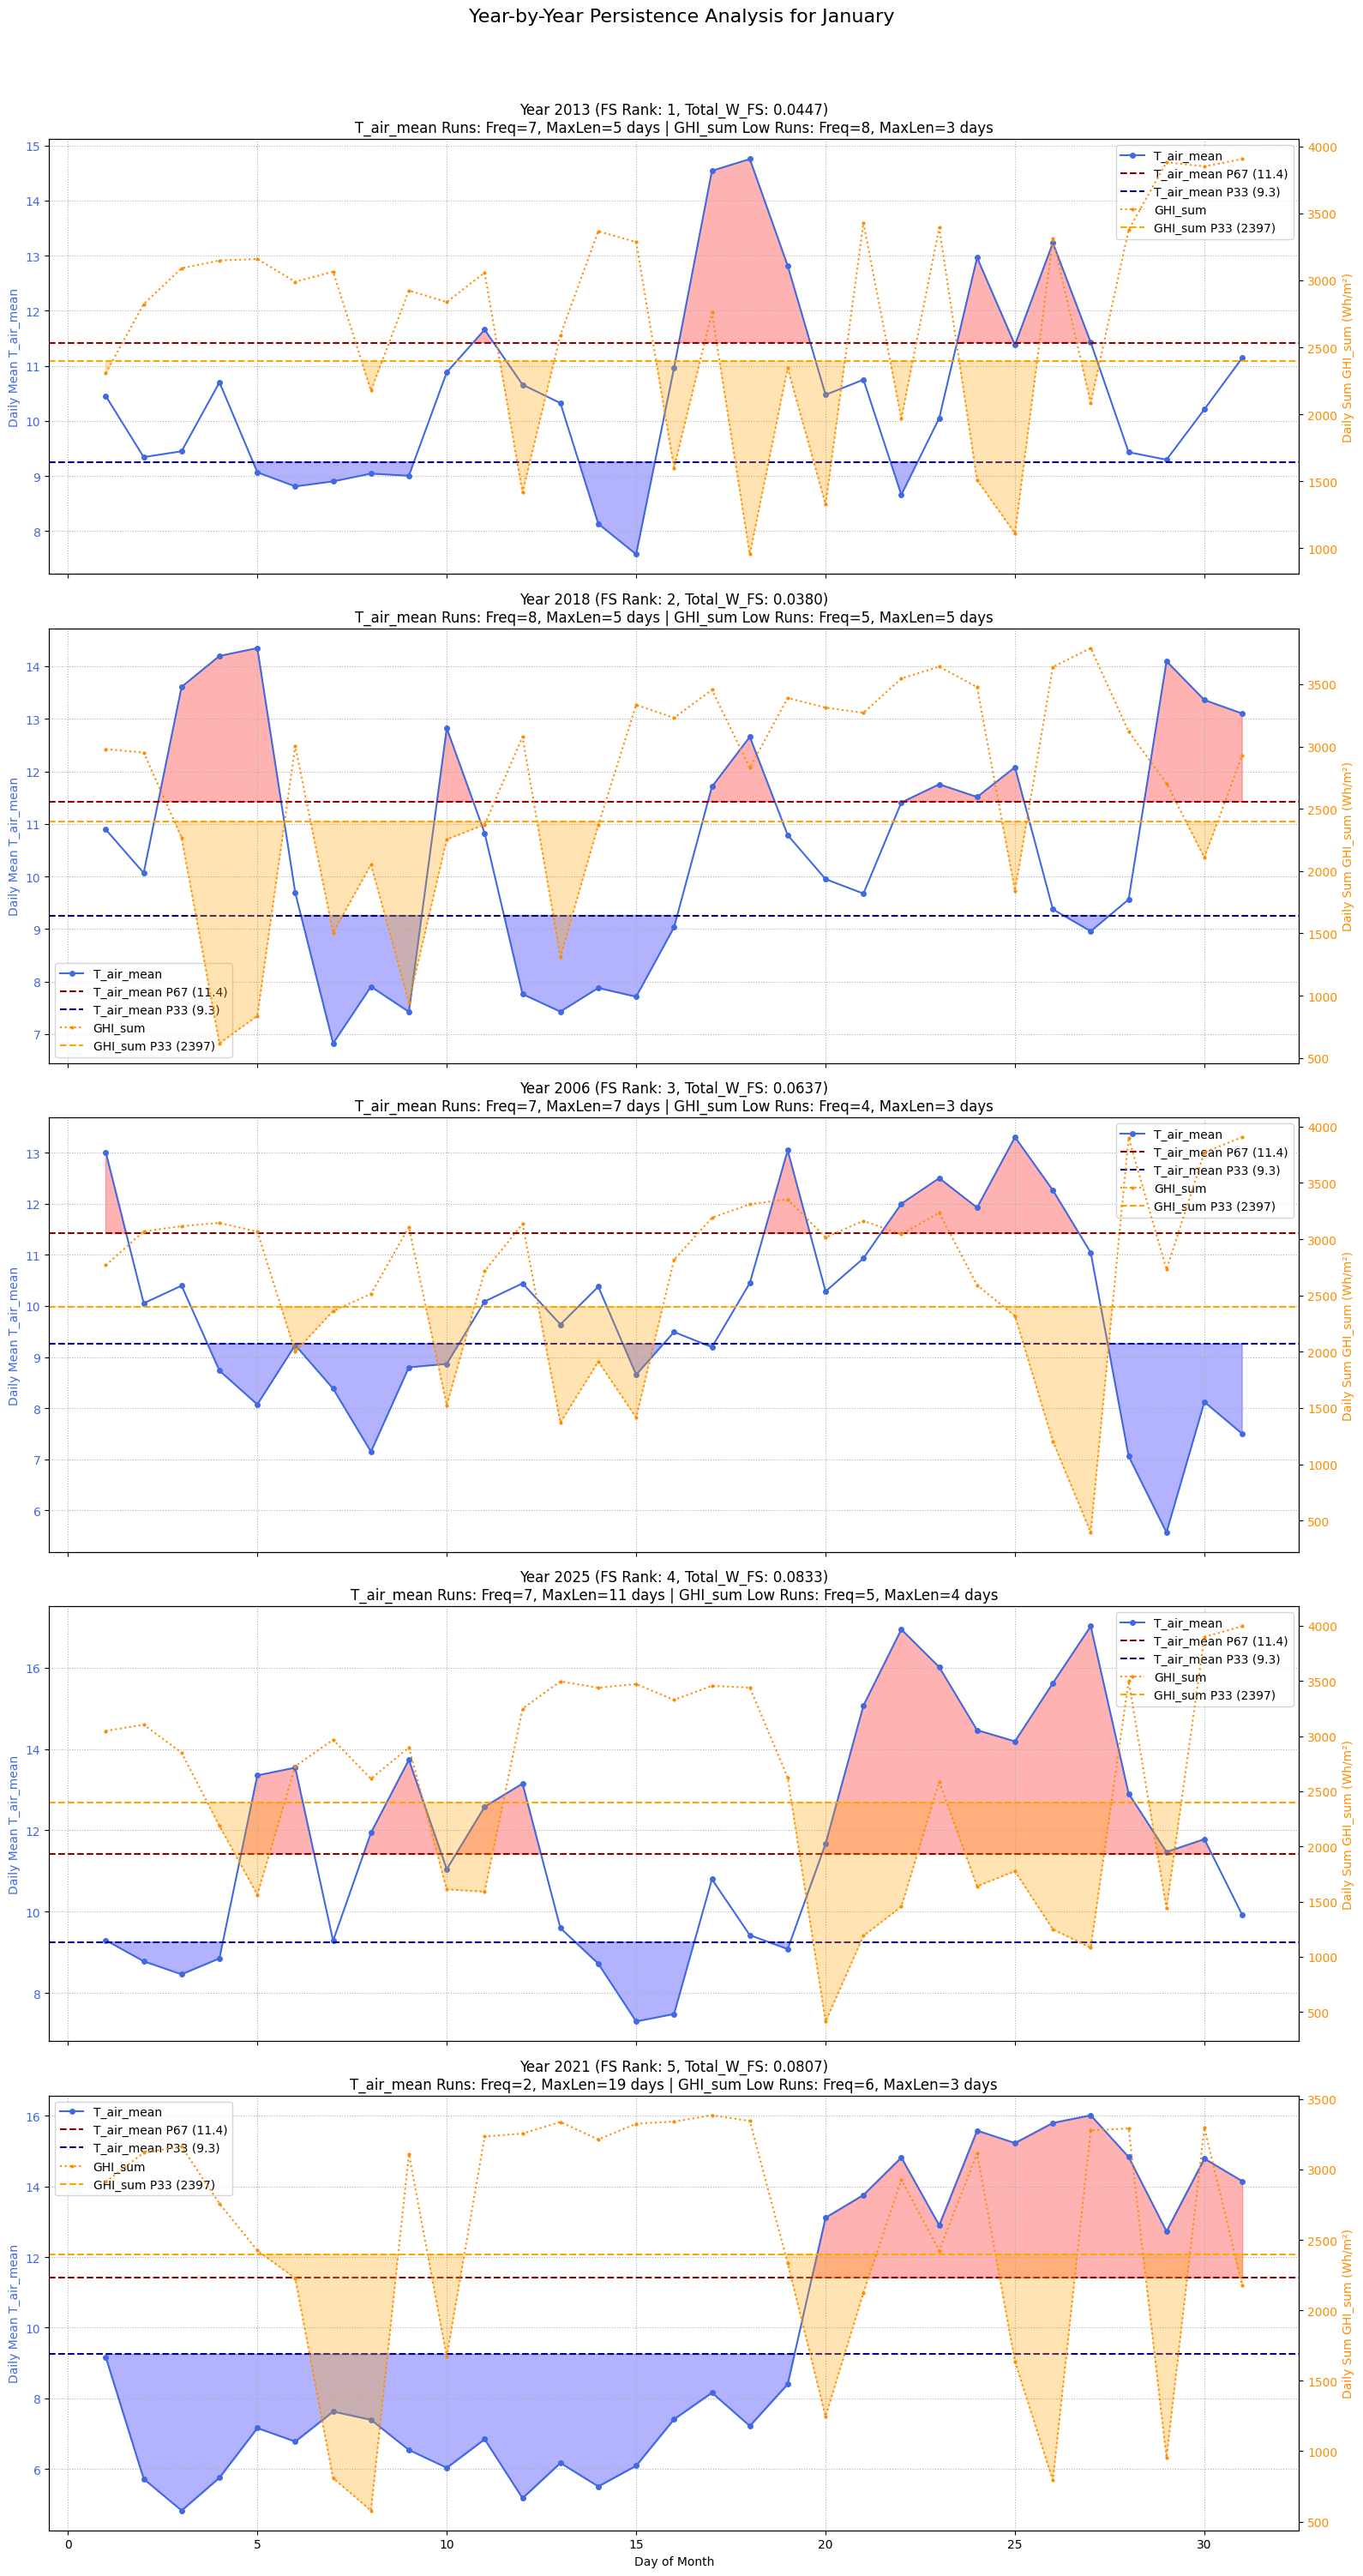

In [22]:
seville_step.plot_persistence_runs(month=1, years=seville_step.candidate_months[1])

#### Step 6 -- Raw TMY assembly (`sandia_step_6_assemble_tmy`)

The twelve selected typical months -- drawn, in general, from different years -- are extracted at hourly resolution, re-indexed onto a common synthetic year (year 2000), stripped of any 29 February, and concatenated into a raw, unsmoothed 8760-hour TMY (`self.tmy_raw`).

In [23]:
seville_step.sandia_step_6_assemble_tmy()


Step 6: Creating raw (un-smoothed) TMY...


`plot_junctions` plots the raw (pre-smoothing) hourly data around a specified list of `(variable, month)` month-to-month junctions, letting us inspect the discontinuities that Step 7 is designed to remove. We look at the January-to-February junction for dry-bulb temperature.


--- Visualizing Raw Month Junctions (Pre-Smoothing) ---


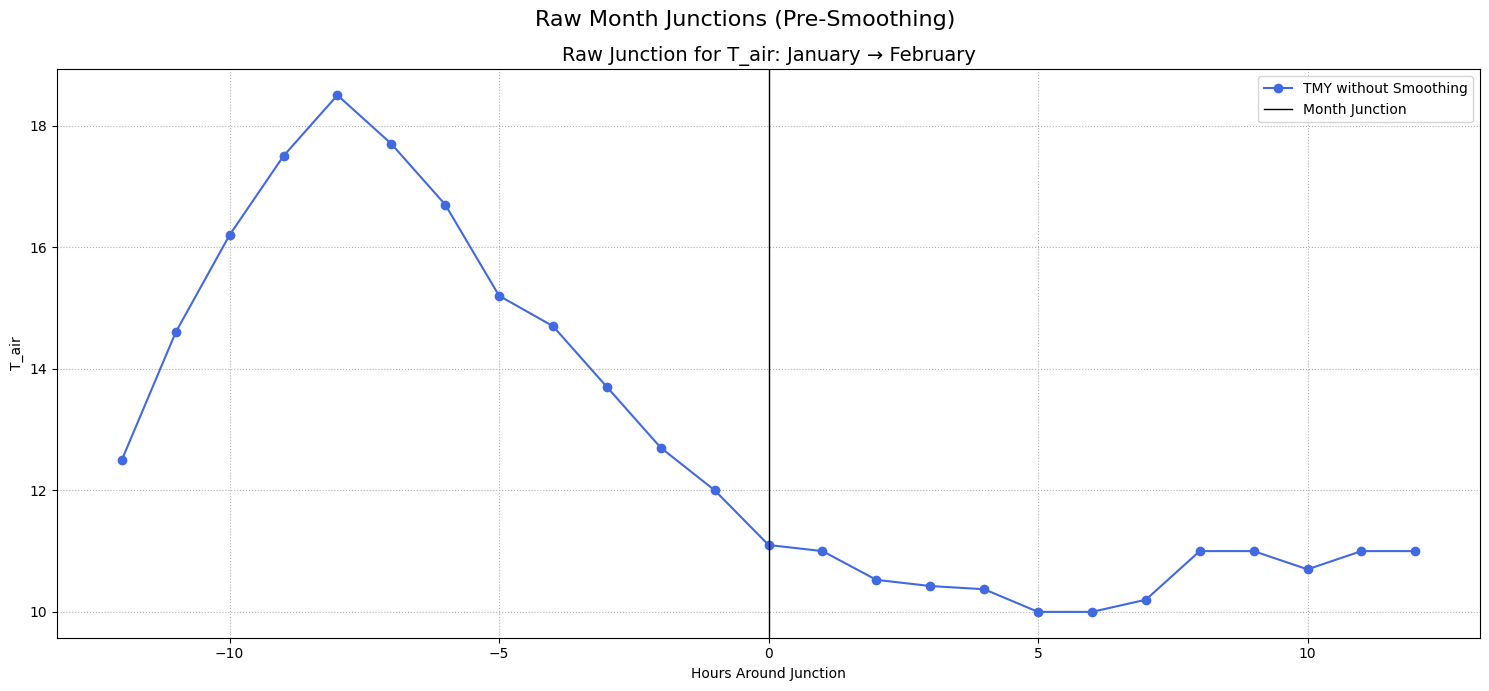

In [24]:
seville_step.plot_junctions(junctions_to_plot=[('T_air', 1)])

#### Step 7 -- Junction smoothing (`sandia_step_7_smooth_junctions`)

For each of the eleven month-to-month junctions, a smoothing spline is fitted to the two complete adjacent source months and evaluated over a window of `hours` (default 6) hours either side of the transition; the raw values inside that window are replaced by the smoothed ones for every variable **except** GHI and DNI, which are left untouched so that the solar geometry of the source data is never distorted. How much smoothing is applied is governed by `s_factor`, which defaults to `'auto'`: for each variable the spline's `s` is computed as `auto_s_strength * n * var(y)` (with `auto_s_strength = 0.02`), i.e. proportional to the variance of the two months being fitted, so that temperature, dew point and wind speed all receive a comparable *relative* amount of smoothing regardless of their units. This is also the step that -- since `save_validation_dfs=True` -- automatically calls `generate_full_summary()` internally.

```{note}
`s_factor` also accepts a plain number, handed verbatim to `scipy.interpolate.UnivariateSpline`. In particular `s_factor=0.0` means *exact interpolation*: the spline passes through every fitted point, the smoothed values come out numerically identical to the raw ones, and the TMY therefore remains strictly made of measured hours (Step 7 still runs, but it is a no-op by construction -- this was the package default before the switch to `auto`). `s_factor=None` falls back to SciPy's own criterion (`s = n`), which is unit-dependent and strong enough to flatten low-variance variables such as wind speed. Per-junction overrides can be passed through `smoothing_config`, e.g. `{1: {'hours_before': 12, 'hours_after': 3}, 7: {'s_factor': 0.0}}`.
```

In [25]:
seville_step.sandia_step_7_smooth_junctions()

Applying sophisticated smoothing at month junctions...
  - Junction 1->2: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 2->3: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 3->4: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 4->5: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 5->6: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


...

  - Junction 8->9: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 9->10: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 10->11: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 11->12: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Fixed 2 negative values in 'Wind_speed' caused by smoothing undershoot.
Final TMY generated and smoothed.
Full summary generated: 12 months. Stored in 'self.validation_full_summary'.


`plot_smoothing_comparison` overlays the raw and the smoothed hourly series around the same junction inspected above, so the effect of Step 7 is directly visible, and reports the parameters actually used in the figure title (`h_before`, `h_after`, and the numeric `s` that `'auto'` resolved to for this particular variable and junction).


--- Comparing Smoothing Effect ---


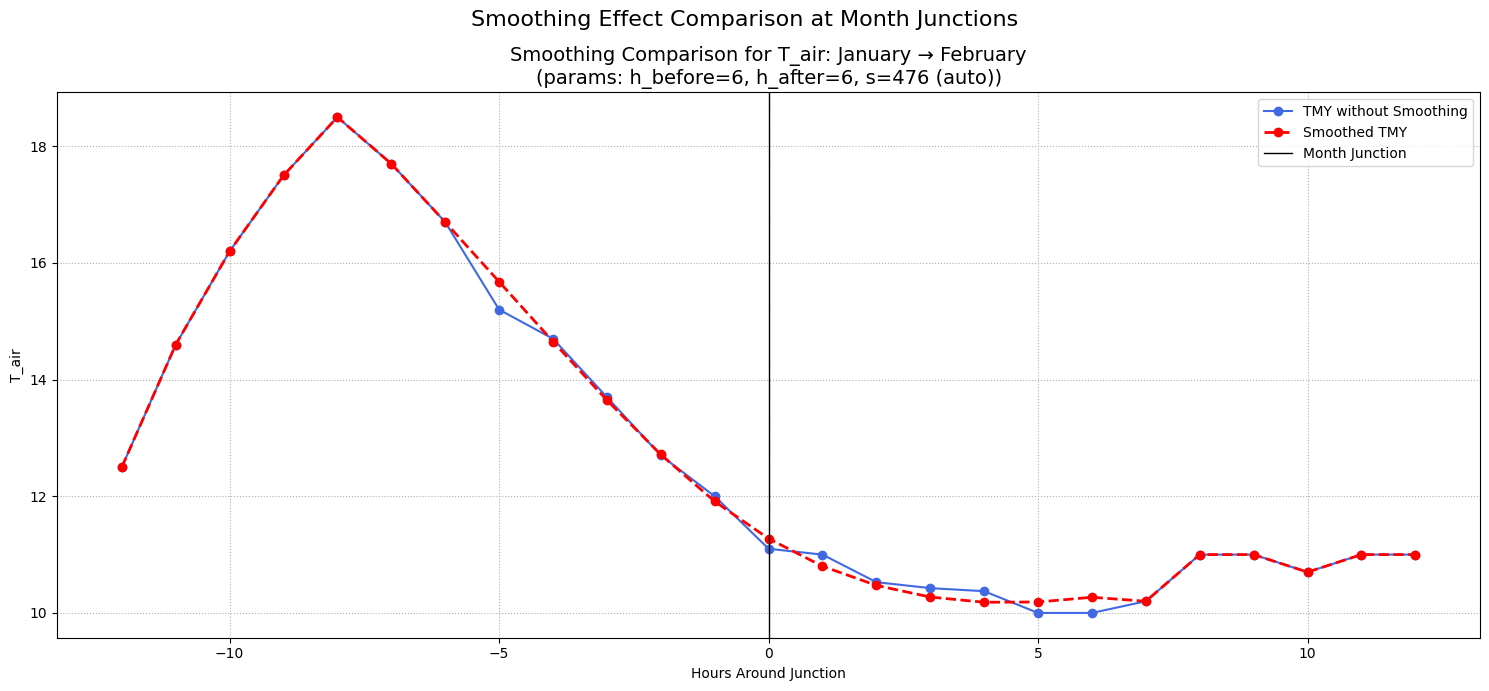

In [26]:
seville_step.plot_smoothing_comparison(junctions_to_plot=[('T_air', 1)])

Step 7 already called `generate_full_summary()` internally, consolidating **one row per month** with the FS score/rank, proximity rank, persistence decision, and the selected year's temperature/GHI deviation from the long-term mean. This single table is the audit trail of the whole pipeline -- it supersedes the per-step composition/statistics dumps -- so we simply display `self.validation_full_summary`.

In [27]:
seville_step.validation_full_summary

,Month,Month_Num,Source_Year,FS_Total_W_FS,FS_Rank_Overall,FS_Num_Years,Prox_Rank,Persist_NumRuns,Persist_MaxRun,Persist_Decision,LT_T_mean,Sel_T_mean,T_diff,LT_GHI_mean,Sel_GHI_mean,GHI_diff
0,January,1,2018,0.038000,1,21,2,13,5,SELECTED TMY MONTH,10.47,10.59,0.13,2599.05,2650.72,51.67
1,February,2,2009,0.070390,1,21,1,9,8,SELECTED TMY MONTH,11.87,12.21,0.34,3411.34,3641.70,230.36
2,March,3,2011,0.052006,1,21,2,9,7,SELECTED TMY MONTH,14.31,14.11,-0.20,4561.48,4466.73,-94.75
3,April,4,2008,0.058805,2,21,2,7,6,SELECTED TMY MONTH,17.19,18.01,0.82,5797.47,6030.03,232.56
4,May,5,2007,0.069847,4,21,1,11,6,SELECTED TMY MONTH,20.96,20.86,-0.10,6884.36,7011.24,126.88
5,June,6,2021,0.077224,4,21,1,7,7,SELECTED TMY MONTH,24.70,24.43,-0.27,7467.65,7922.03,454.38
6,July,7,2013,0.055516,2,21,1,10,7,SELECTED TMY MONTH,27.20,27.40,0.20,7732.57,8025.17,292.60
7,August,8,2021,0.068468,4,21,2,11,6,SELECTED TMY MONTH,27.45,28.09,0.64,6836.35,7094.43,258.08
8,September,9,2021,0.059303,4,21,2,9,4,SELECTED TMY MONTH,23.91,24.47,0.56,5339.27,5552.96,213.69
9,October,10,2013,0.050059,2,21,1,10,8,SELECTED TMY MONTH,20.31,20.60,0.29,3800.07,4019.85,219.78


#### Post-generation diagnostics and plots

With the TMY fully generated, `TMYGenerator` exposes a further set of analysis and plotting methods operating on the final result.

`analyze_selection` flags any month whose selected year deviates from the long-term mean temperature and/or GHI beyond a threshold (`temp_diff_threshold=1.0` degrees Celsius by default; `ghi_diff_threshold=None` disables the GHI check unless set). It returns the audit as a DataFrame (also stored in `validation_selection_analysis`); we pass `verbose=False` so that the table is rendered instead of printed as fixed-width text. The `Flagged` column is the summary of the check: all `False` means every month is within tolerance.

In [28]:
seville_step.analyze_selection(temp_diff_threshold=1.0, verbose=False)

,Month,Month_Num,Selected_Year,FS_Rank_of_5,T_mean_LT,T_mean_Selected,T_diff,T_pctil,Flagged_T,GHI_mean_LT,GHI_mean_Selected,GHI_diff,GHI_pctil,Flagged_GHI,Flagged
0,January,1,2018,2,10.47,10.59,0.13,61.9,False,2599.05,2650.72,51.67,38.1,False,False
1,February,2,2009,1,11.87,12.21,0.34,52.4,False,3411.34,3641.70,230.36,52.4,False,False
2,March,3,2011,2,14.31,14.11,-0.20,33.3,False,4561.48,4466.73,-94.75,28.6,False,False
3,April,4,2008,2,17.19,18.01,0.82,61.9,False,5797.47,6030.03,232.56,52.4,False,False
4,May,5,2007,1,20.96,20.86,-0.10,28.6,False,6884.36,7011.24,126.88,33.3,False,False
5,June,6,2021,1,24.70,24.43,-0.27,38.1,False,7467.65,7922.03,454.38,61.9,False,False
6,July,7,2013,1,27.20,27.40,0.20,28.6,False,7732.57,8025.17,292.60,23.8,False,False
7,August,8,2021,2,27.45,28.09,0.64,52.4,False,6836.35,7094.43,258.08,33.3,False,False
8,September,9,2021,2,23.91,24.47,0.56,42.9,False,5339.27,5552.96,213.69,42.9,False,False
9,October,10,2013,1,20.31,20.60,0.29,47.6,False,3800.07,4019.85,219.78,52.4,False,False


`plot_monthly_trend` plots the year-by-year evolution of a variable's monthly mean, starring the TMY-selected year and drawing its linear trend line (`show_candidates=True` additionally overlays the other Top-5 candidates). `plot_monthly_series` plots the full daily series of every available year for the requested month(s), highlighting the selected year.

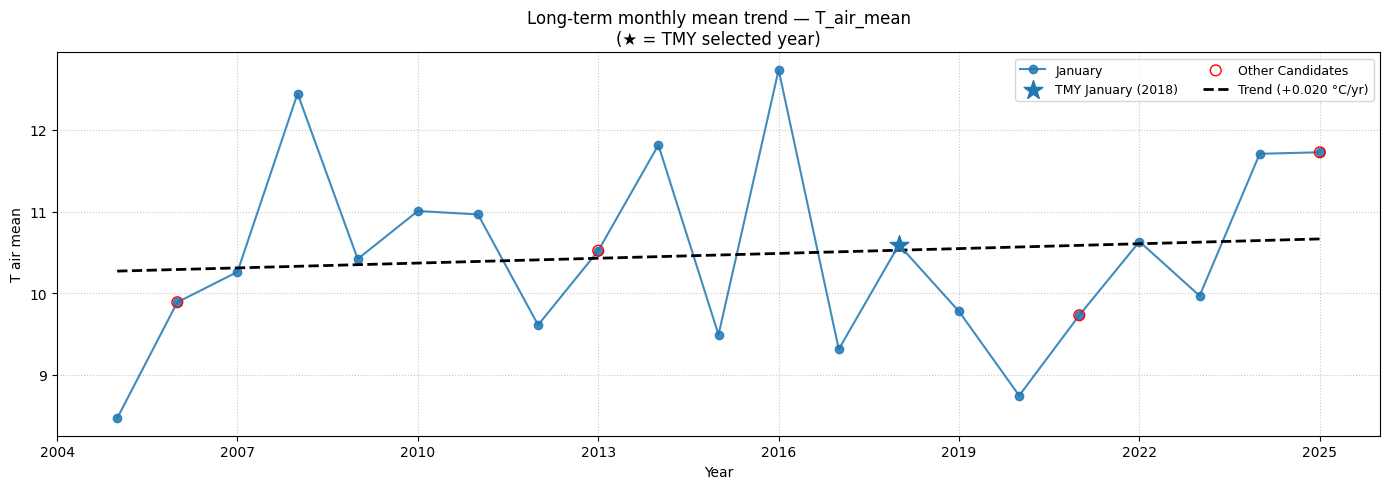

In [29]:
fig_trend_jan = seville_step.plot_monthly_trend(variable='T_air_mean', months=[1], show_candidates=True)

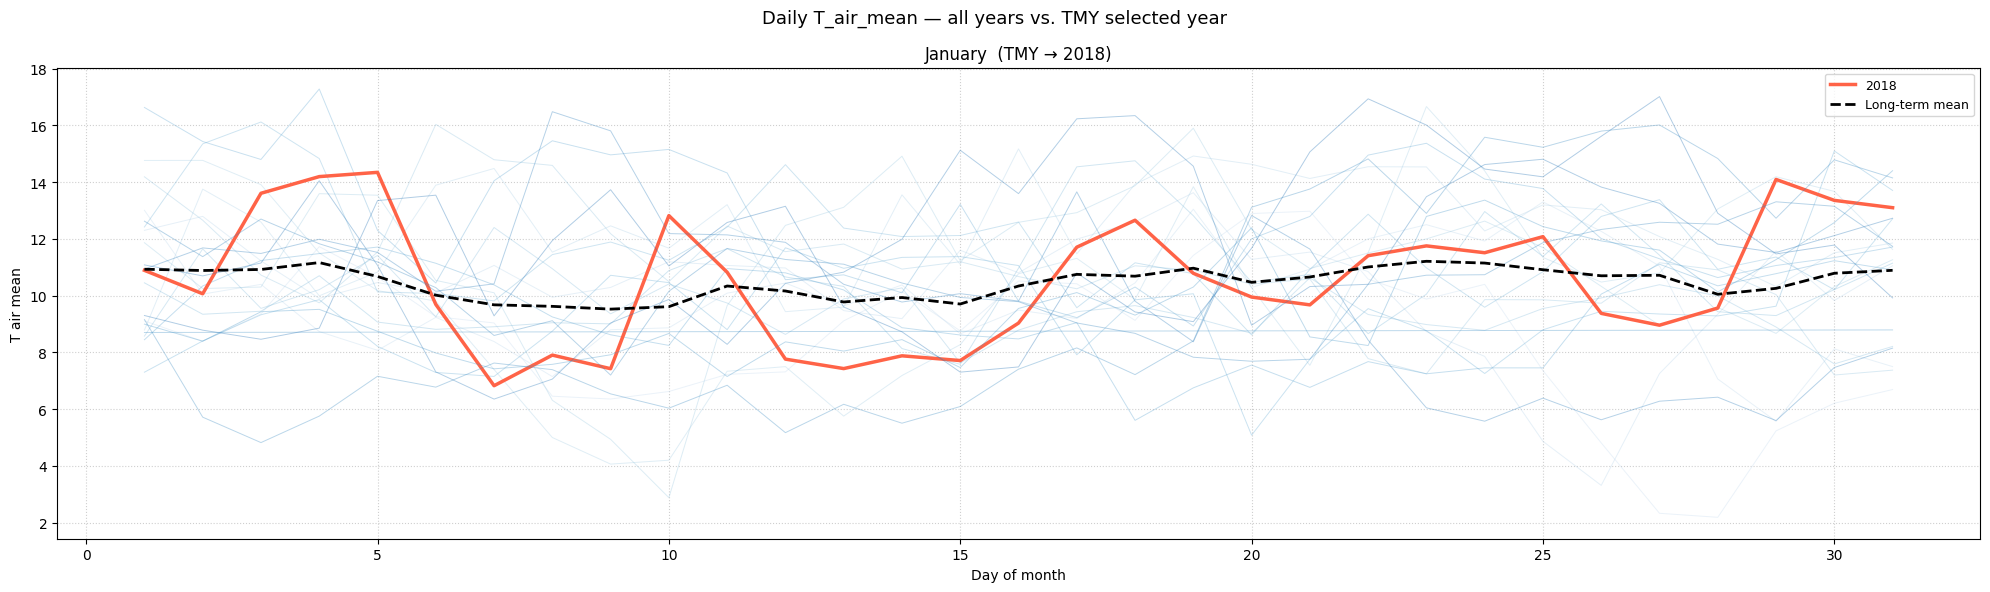

In [30]:
fig_series_jan = seville_step.plot_monthly_series(variable='T_air_mean', months=[1])

Three further plots summarise the final TMY against the long-term climate as a whole: `plot_annual_cdfs` (annual CDF of the TMY vs. long-term, for temperature/dew point/wind/GHI), `plot_monthly_means` (monthly mean of the TMY vs. long-term for the same four variables) and `plot_monthly_cdfs` (a 12-month grid of CDF comparisons per variable).


--- Plotting Annual CDF Comparison: Final TMY vs. Long-term ---


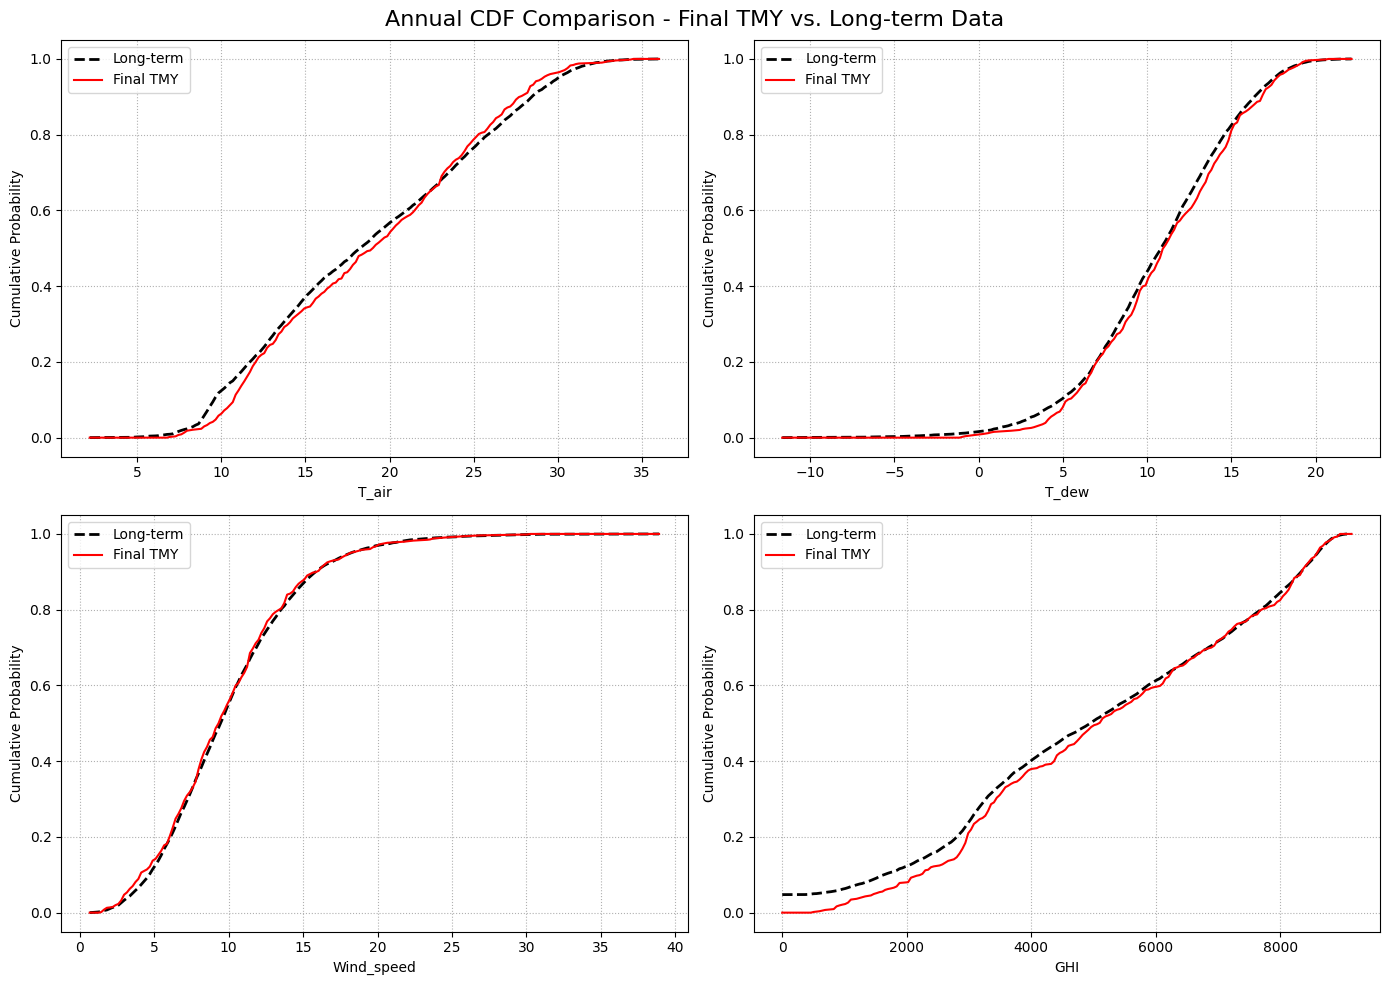

In [31]:
seville_step.plot_annual_cdfs()


--- Plotting Monthly Mean Comparison: Final TMY vs. Long-term ---


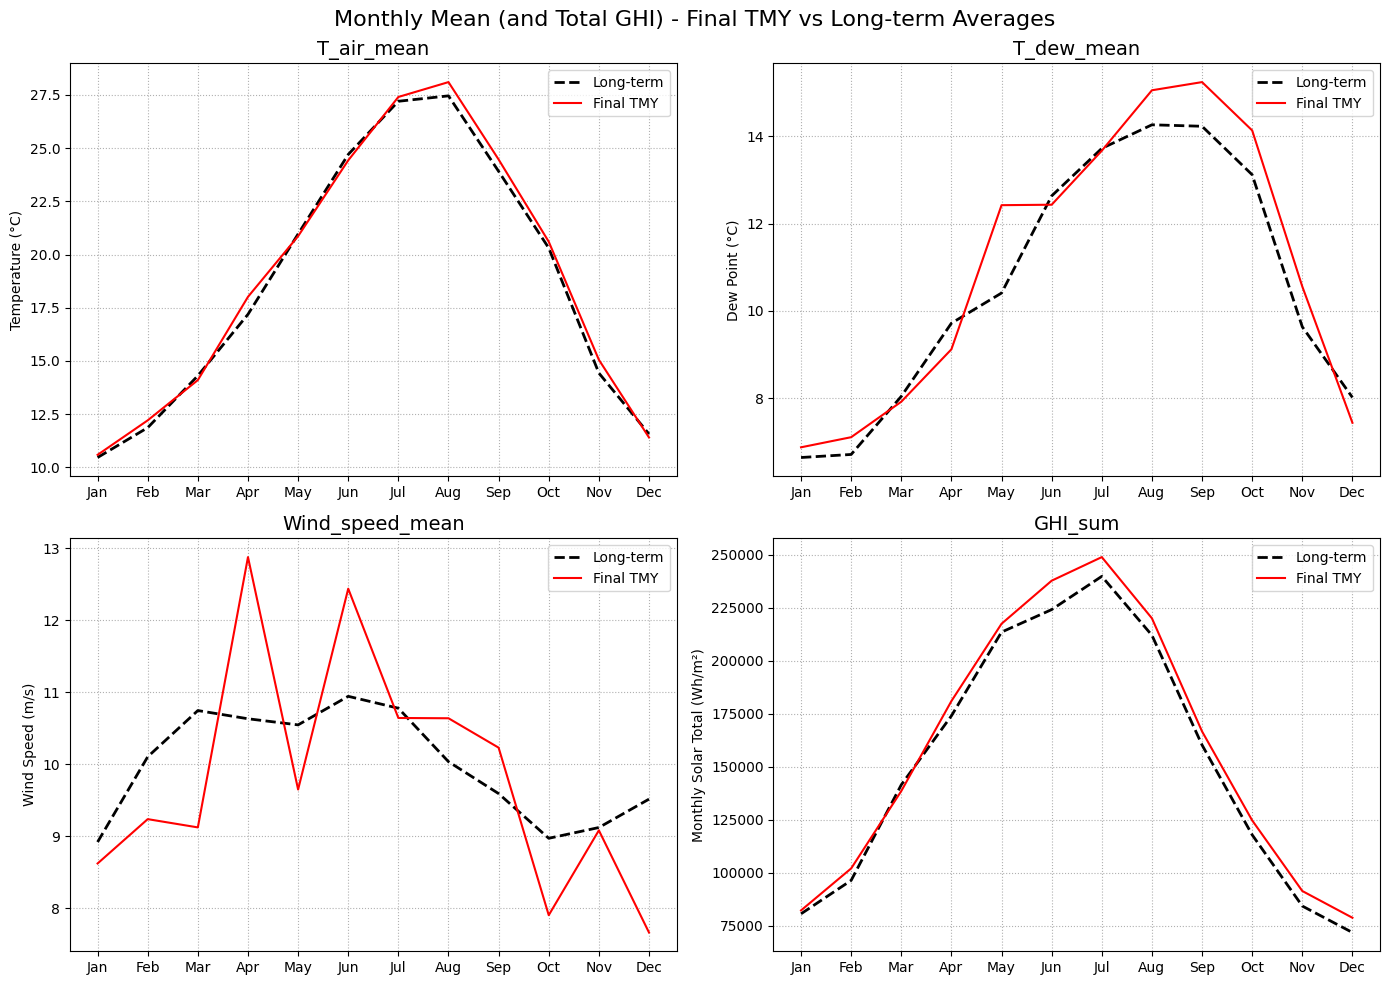

In [32]:
seville_step.plot_monthly_means()


--- Plotting Monthly CDF Comparison: Final TMY vs. Long-term ---


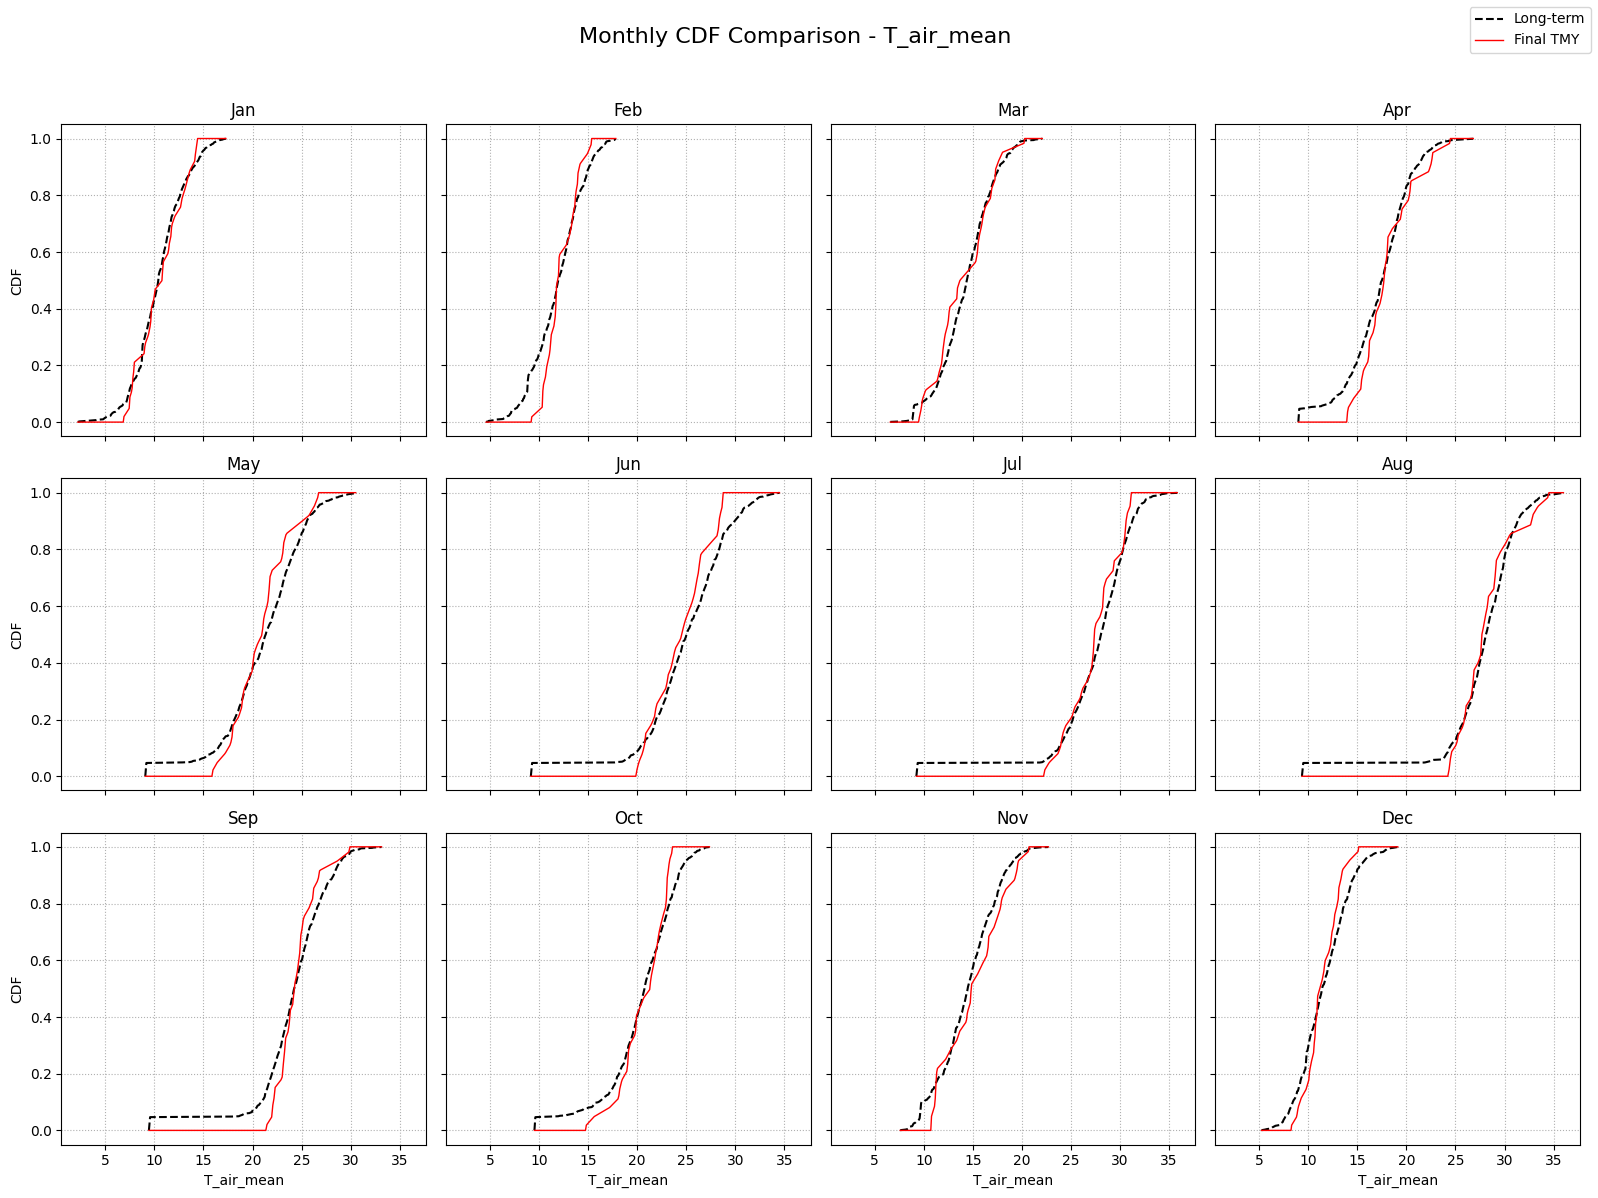

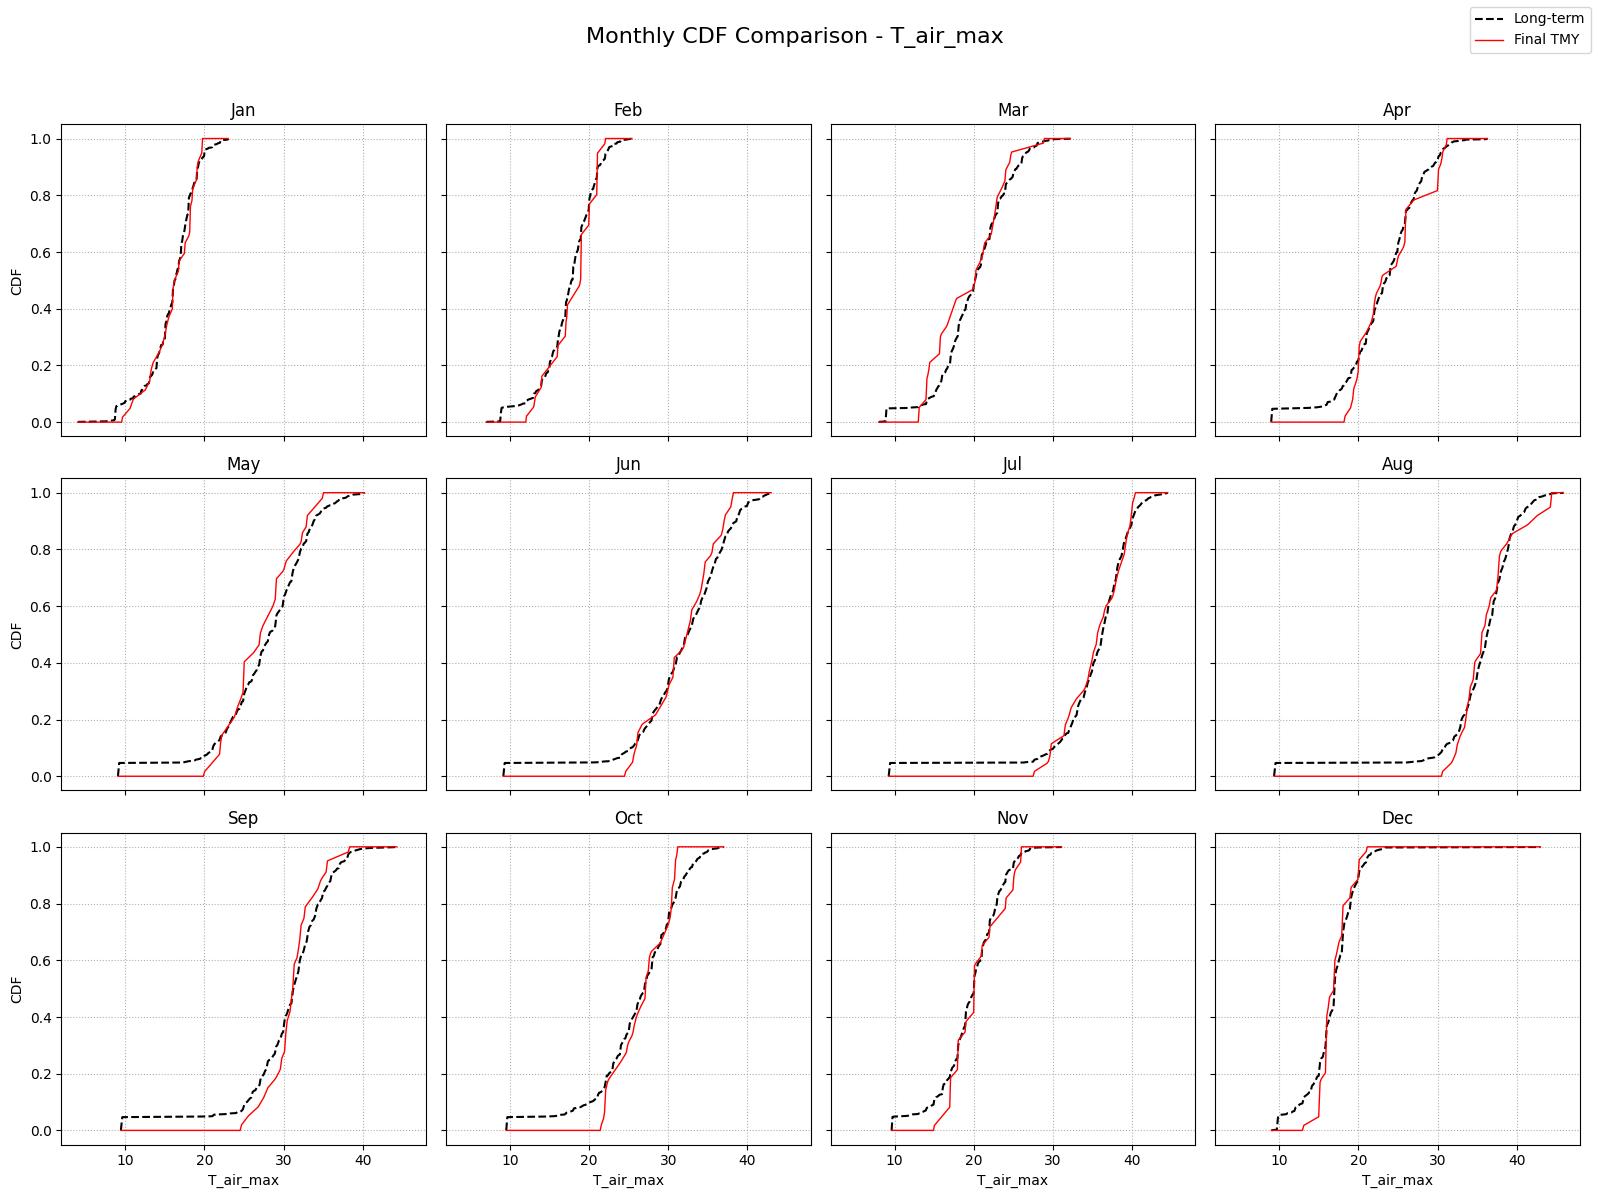

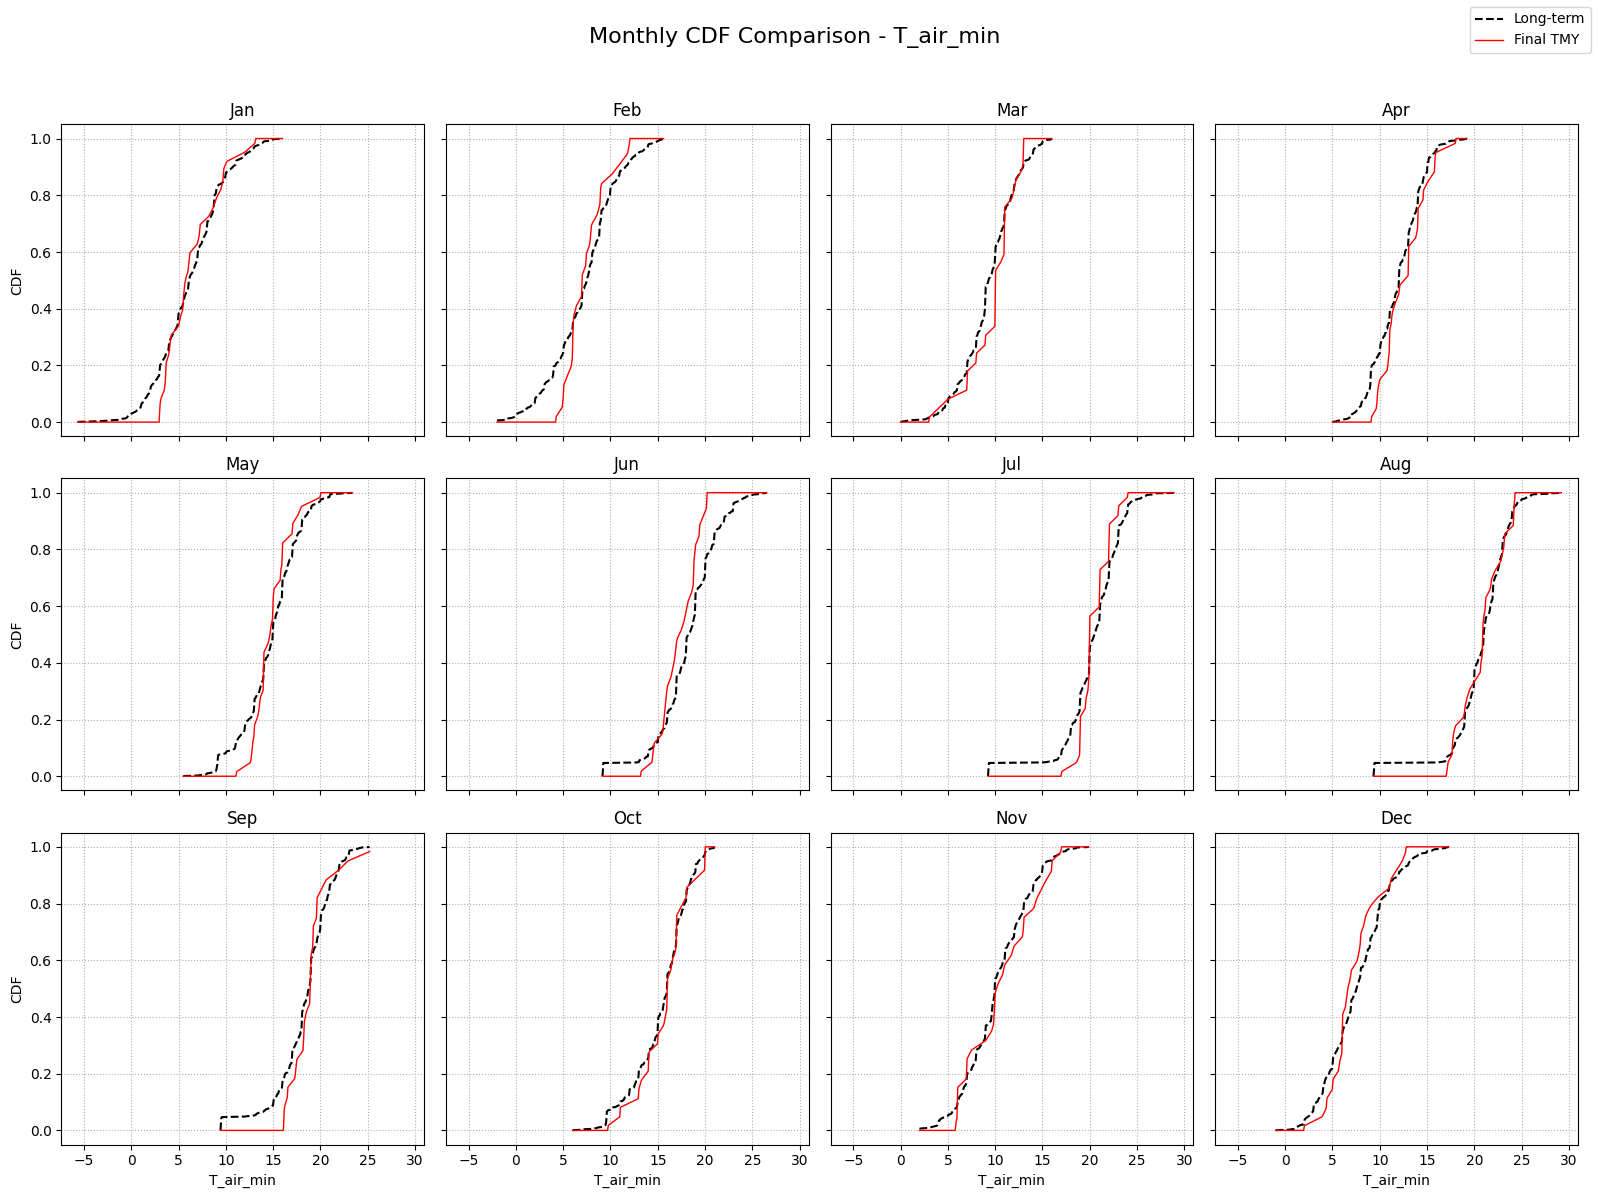

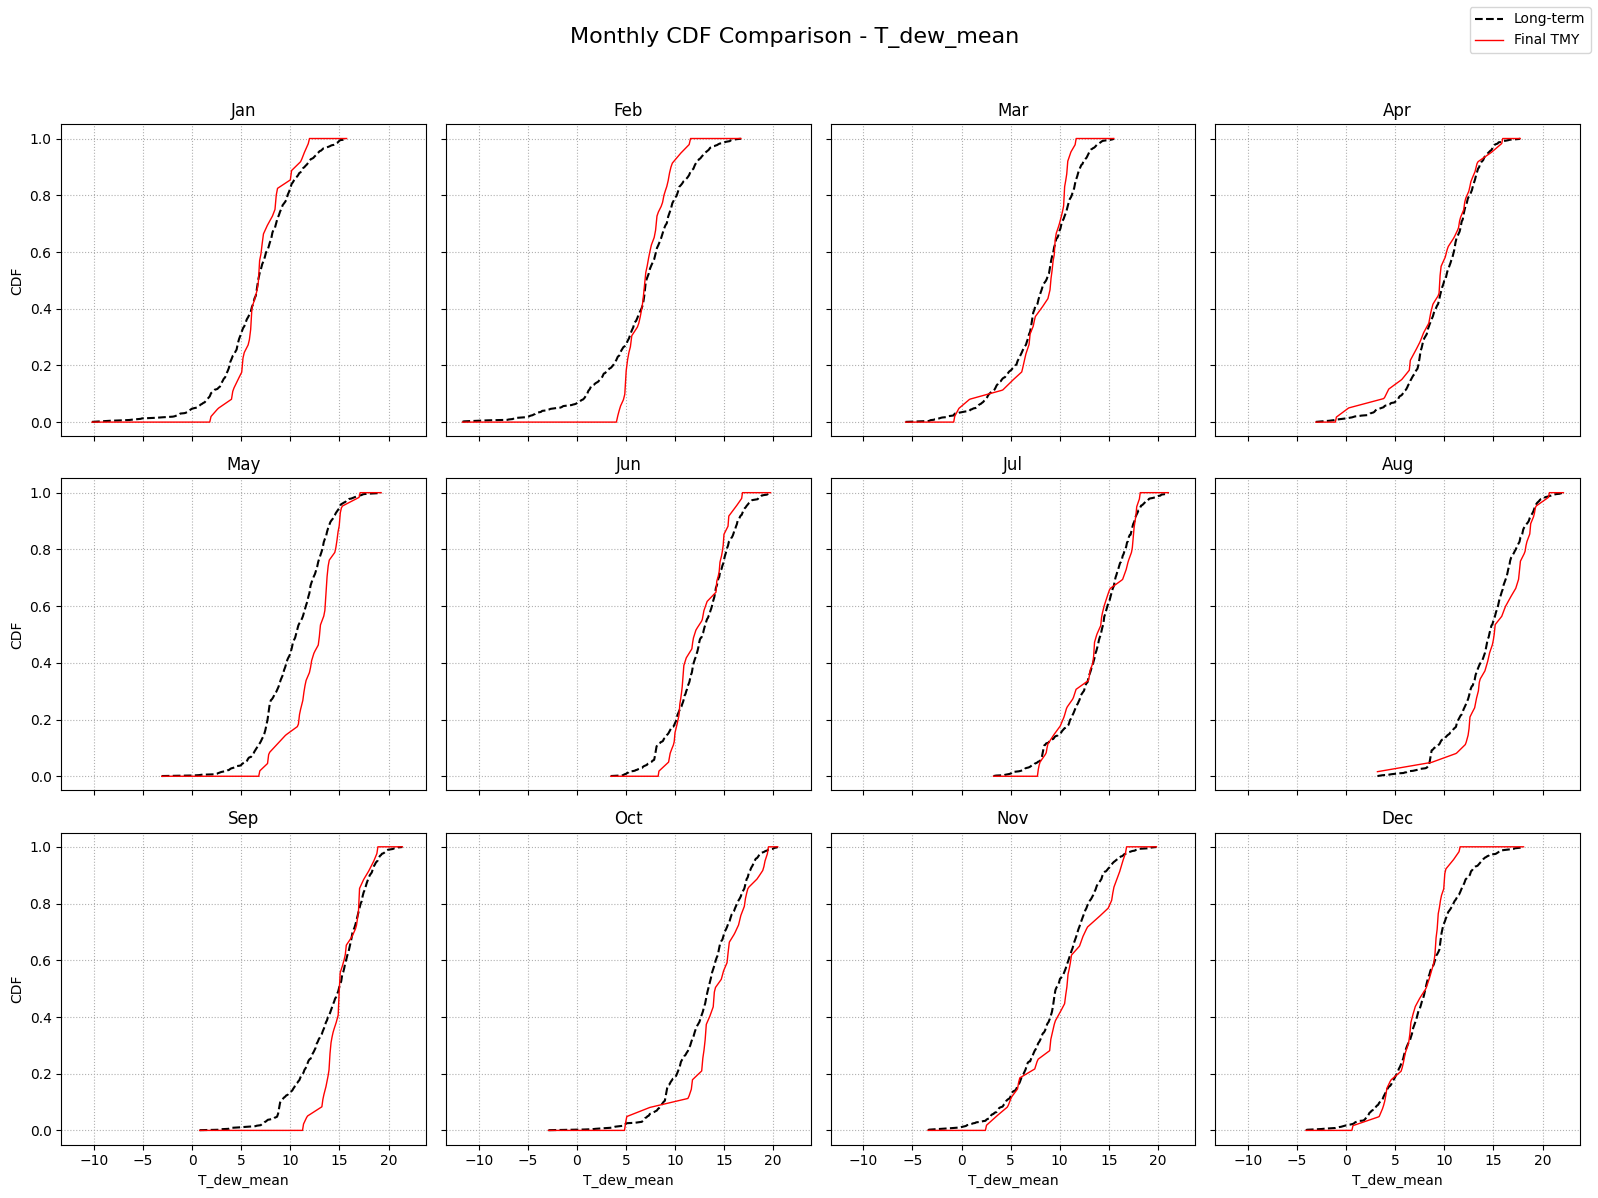

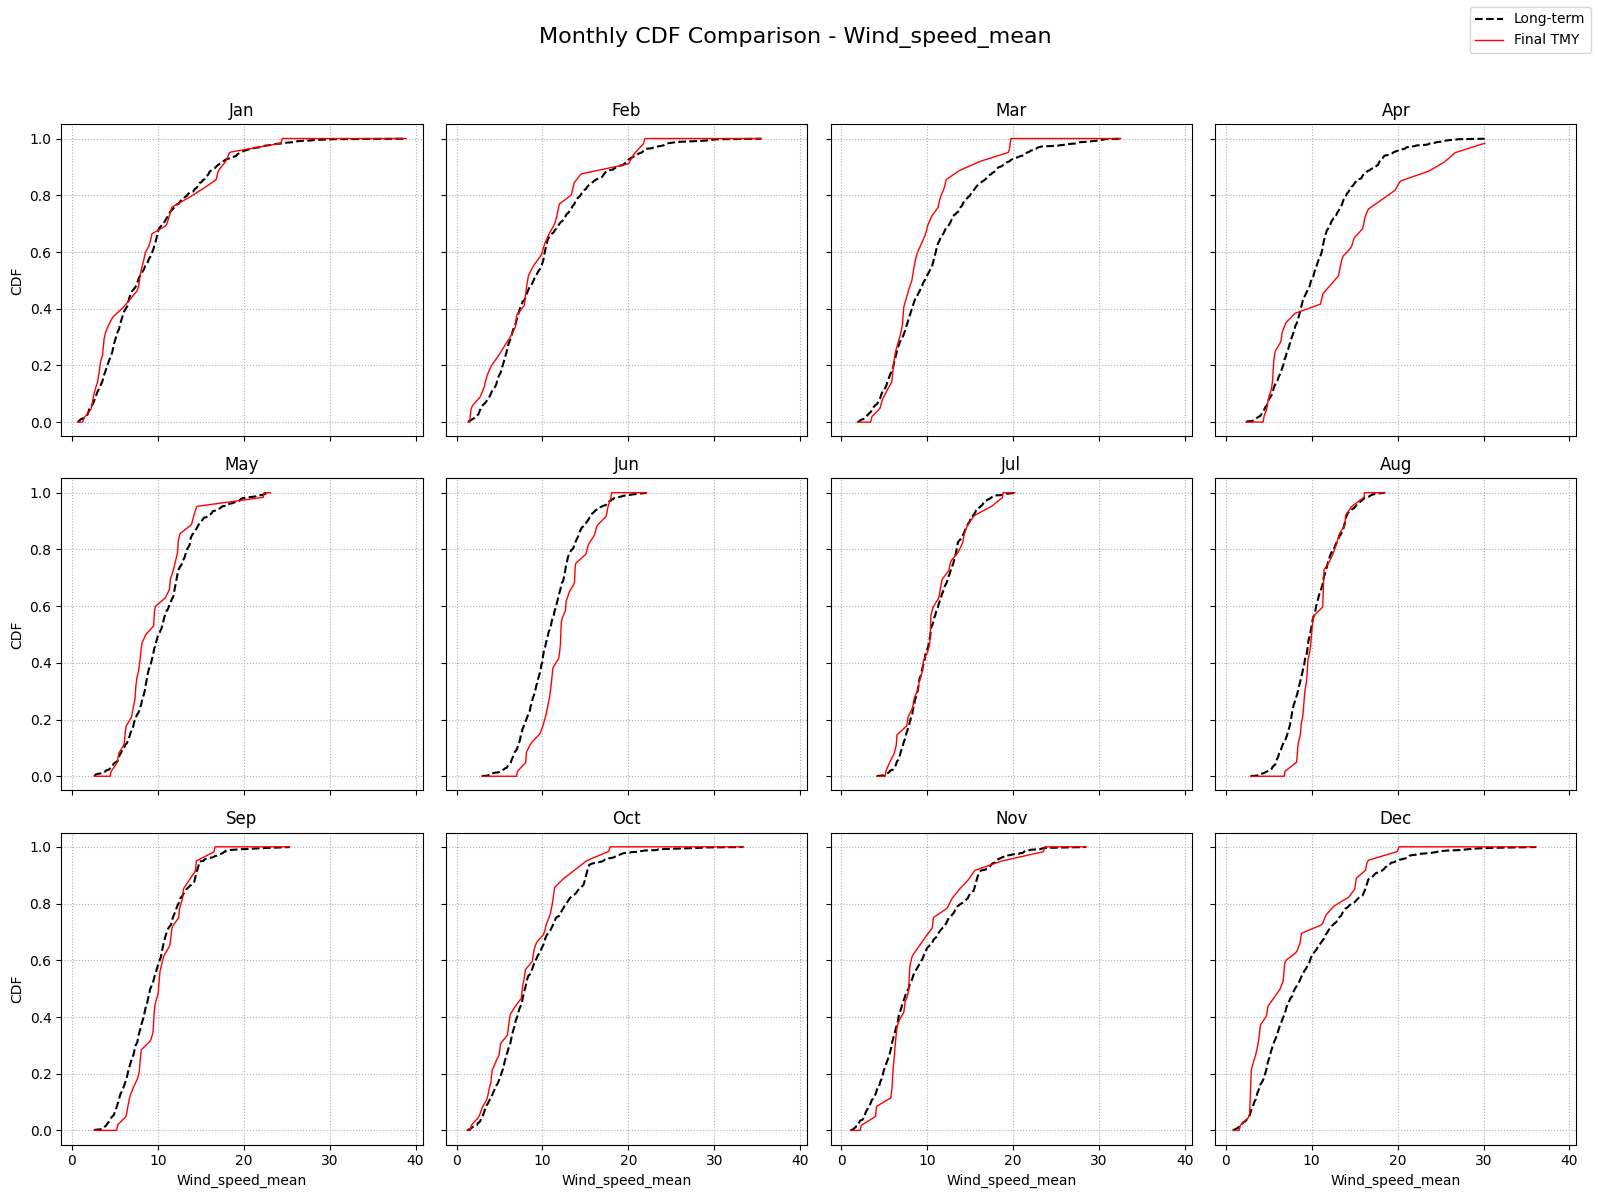

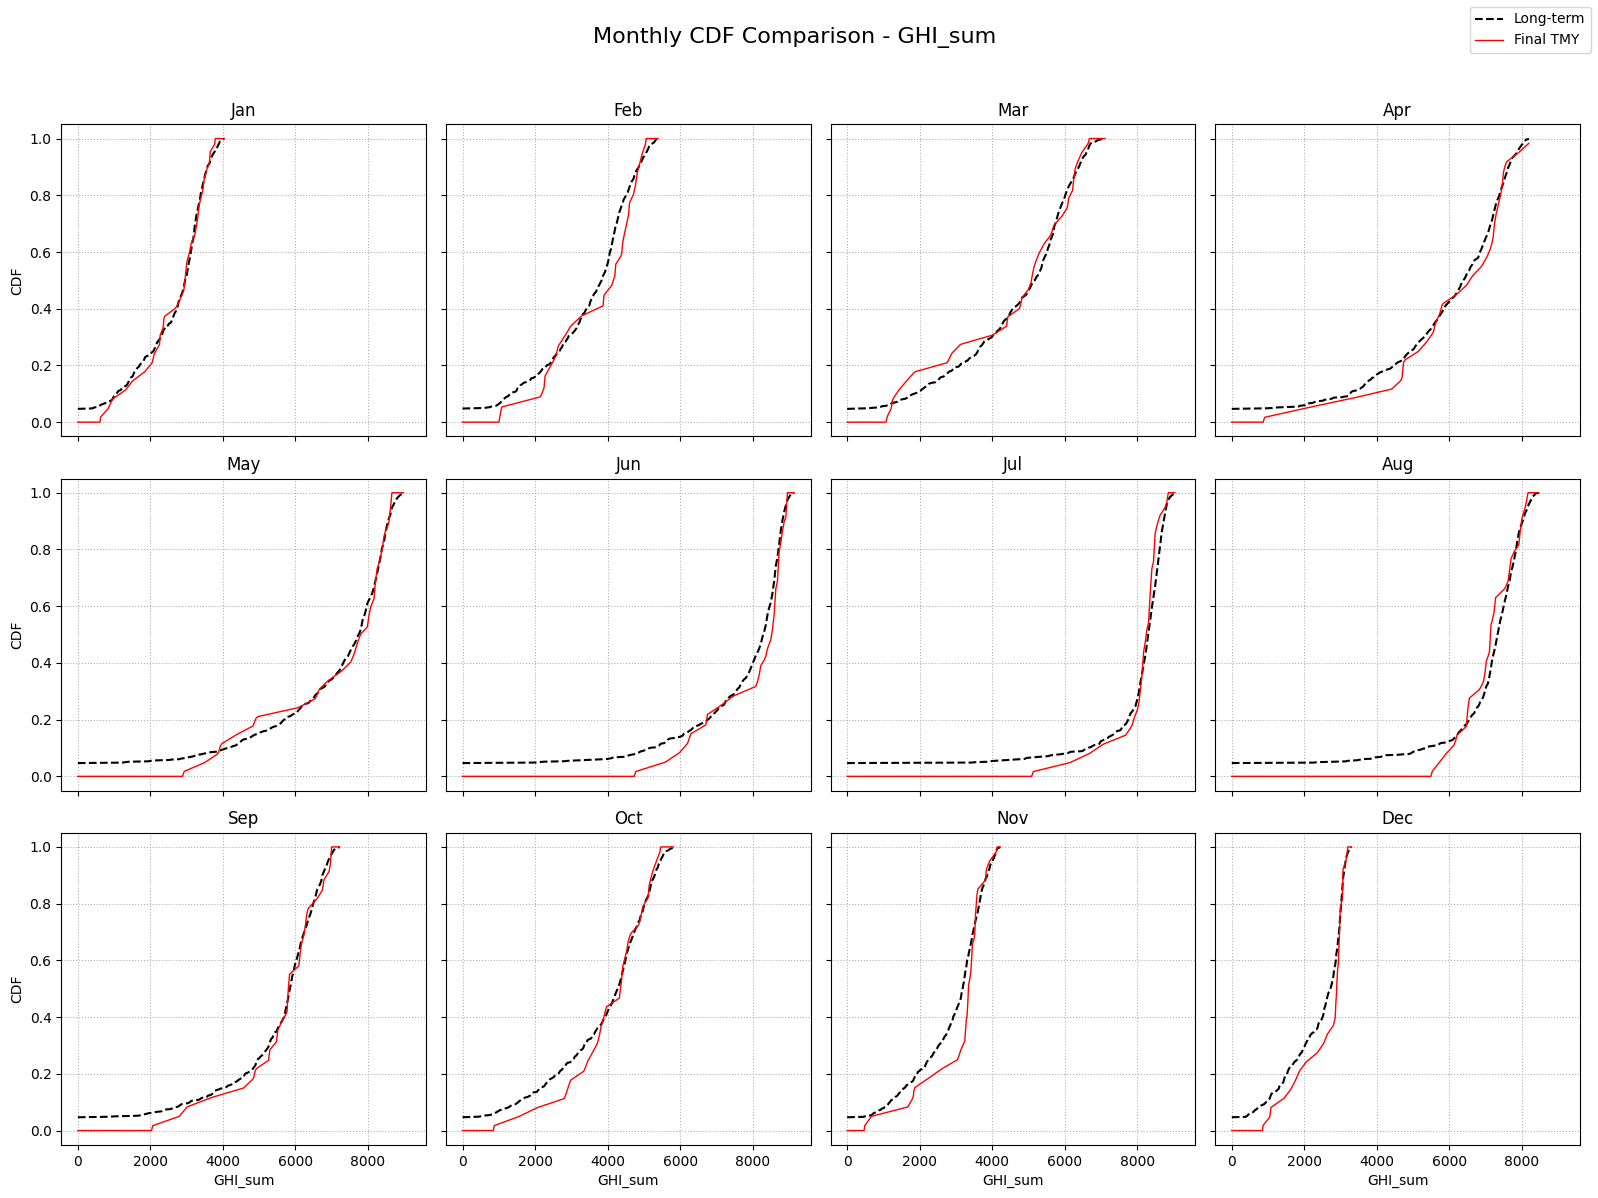

In [33]:
seville_step.plot_monthly_cdfs()

Finally, `correct_selection_by_temperature` offers an optional corrective pass: for any month whose selected year's temperature deviates from the long-term mean by more than `temp_diff_threshold`, it swaps in the Top-5 candidate that minimises that deviation and, since `regenerate=True` (default), re-assembles and re-smooths the TMY in place. `analyze_selection` above already reported zero flagged months for Seville with the standard 1 degC threshold, so we expect an empty corrections dictionary here -- itself a positive validation result, confirming that the automatically selected TMY already matches the long-term mean within 1 degC for every month.

In [34]:
corrections = seville_step.correct_selection_by_temperature(temp_diff_threshold=1.0)


  CORRECTION REPORT  (threshold = |1.0| °C)
  No corrections needed within the specified months.



In [35]:
corrections

{}

`export_tmy` writes the final TMY to disk. Any variable present in `df_hourly` but absent from `tmy_final` is assembled the same way as the TMY and appended, and the original source column names are restored (the inverse of the `col_*` mapping) -- which is exactly what lets `HourlyEPWConverter` (Part 2) consume the exported file directly, without any extra `column_mapping`.

In [36]:
seville_step.export_tmy(os.path.join(OUT_DIR, 'seville_tmy_stepbystep.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy_stepbystep.csv'...
Export completed successfully.


### Part 1.2 -- Seville: single-call generation and cross-check

`generate_tmy()` runs the same seven steps in a single call. We instantiate a **fresh** `TMYGenerator` (identical constructor arguments to Part 1.1) so the comparison is not influenced by the correction pass just applied above. `use_persistence=True` enables Steps 4-5 (as opposed to falling back to the plain FS ranking), and `persistence_method='sequential'` plus `proximity_normalization_method='std'` match Part 1.1 exactly, so the two runs should select the same twelve typical months. This time we keep the default `save_session=True`, so a reproducible `.pkl`/`.json` session snapshot is written next to the output.

In [37]:
seville_direct = tmy.TMYGenerator(
    file_path=SEVILLE['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=SEVILLE['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


In [38]:
seville_direct = seville_direct.generate_tmy(
    use_persistence=True,
    persistence_method='sequential',
    proximity_normalization_method='std',
)

--- Starting full TMY generation workflow ---
Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Seville_hourly_data.xlsx'...


Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]


Resampling data to hourly frequency and interpolating gaps...


Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Seville_hourly_data.xlsx'...


Resampling hourly data and interpolating gaps...


...

  - Junction 8->9: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 9->10: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 10->11: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 11->12: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Fixed 2 negative values in 'Wind_speed' caused by smoothing undershoot.
Final TMY generated and smoothed.
Full summary generated: 12 months. Stored in 'self.validation_full_summary'.
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\TMYGenerator_Seville_hourly_data_daily_sandia_ba6f5926.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\TMYGenerator_Seville_hourly_data_daily_sandia_ba6f5926.json

--- Full TMY generation finished ---


In [39]:
seville_direct.export_tmy(os.path.join(OUT_DIR, 'seville_tmy_direct.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy_direct.csv'...


Export completed successfully.


Both runs used the same input data and configuration, so `compare_tmy_versions` should show the step-by-step (pre-correction) and direct results overlapping almost exactly for every month -- any residual difference stems solely from the temperature correction applied at the end of Part 1.1.

D:\Python\pyweatherfiles\pyweatherfiles\tmy\_plotting.py:1202: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


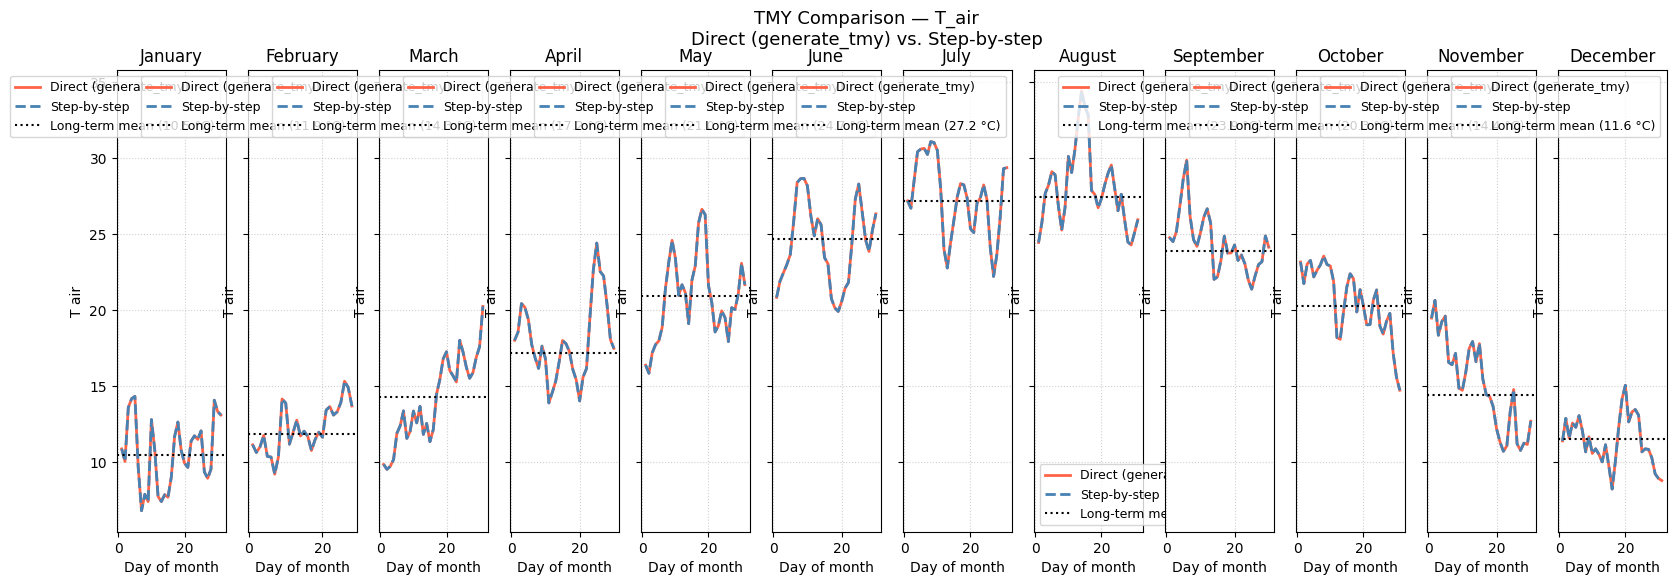

In [40]:
fig_compare_seville = seville_direct.compare_tmy_versions(
    other_tmy_df=seville_step.tmy_final,
    label_self='Direct (generate_tmy)',
    label_other='Step-by-step',
    variable='T_air',
)

### Part 1.3 -- Madrid: condensed single-call generation

We repeat the single-call workflow for Madrid. Its hourly file may use different column headers than Seville's; Part 0's pre-flight check already highlighted any mismatch, so the `column_mapping`/`col_*` arguments below are adjusted accordingly before instantiating the generator.

In [41]:
madrid_tmy_gen = tmy.TMYGenerator(
    file_path=MADRID['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=MADRID['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


In [42]:
madrid_tmy_gen = madrid_tmy_gen.generate_tmy(
    use_persistence=True,
    persistence_method='sequential',
)

--- Starting full TMY generation workflow ---
Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_hourly_data.xlsx'...


Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Resampling data to hourly frequency and interpolating gaps...
Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_hourly_data.xlsx'...


Resampling hourly data and interpolating gaps...
Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 184080 records.
Real data loaded and prepared.
Step 2: Calculating FS statistics using 'daily' method...


D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:178: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:182: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


...

  - Junction 8->9: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 9->10: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 10->11: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Junction 11->12: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)


  - Fixed 3 negative values in 'Wind_speed' caused by smoothing undershoot.
Final TMY generated and smoothed.
Full summary generated: 12 months. Stored in 'self.validation_full_summary'.
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\TMYGenerator_Madrid_hourly_data_daily_sandia_ecd68a45.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\TMYGenerator_Madrid_hourly_data_daily_sandia_ecd68a45.json

--- Full TMY generation finished ---



--- Plotting Monthly Mean Comparison: Final TMY vs. Long-term ---


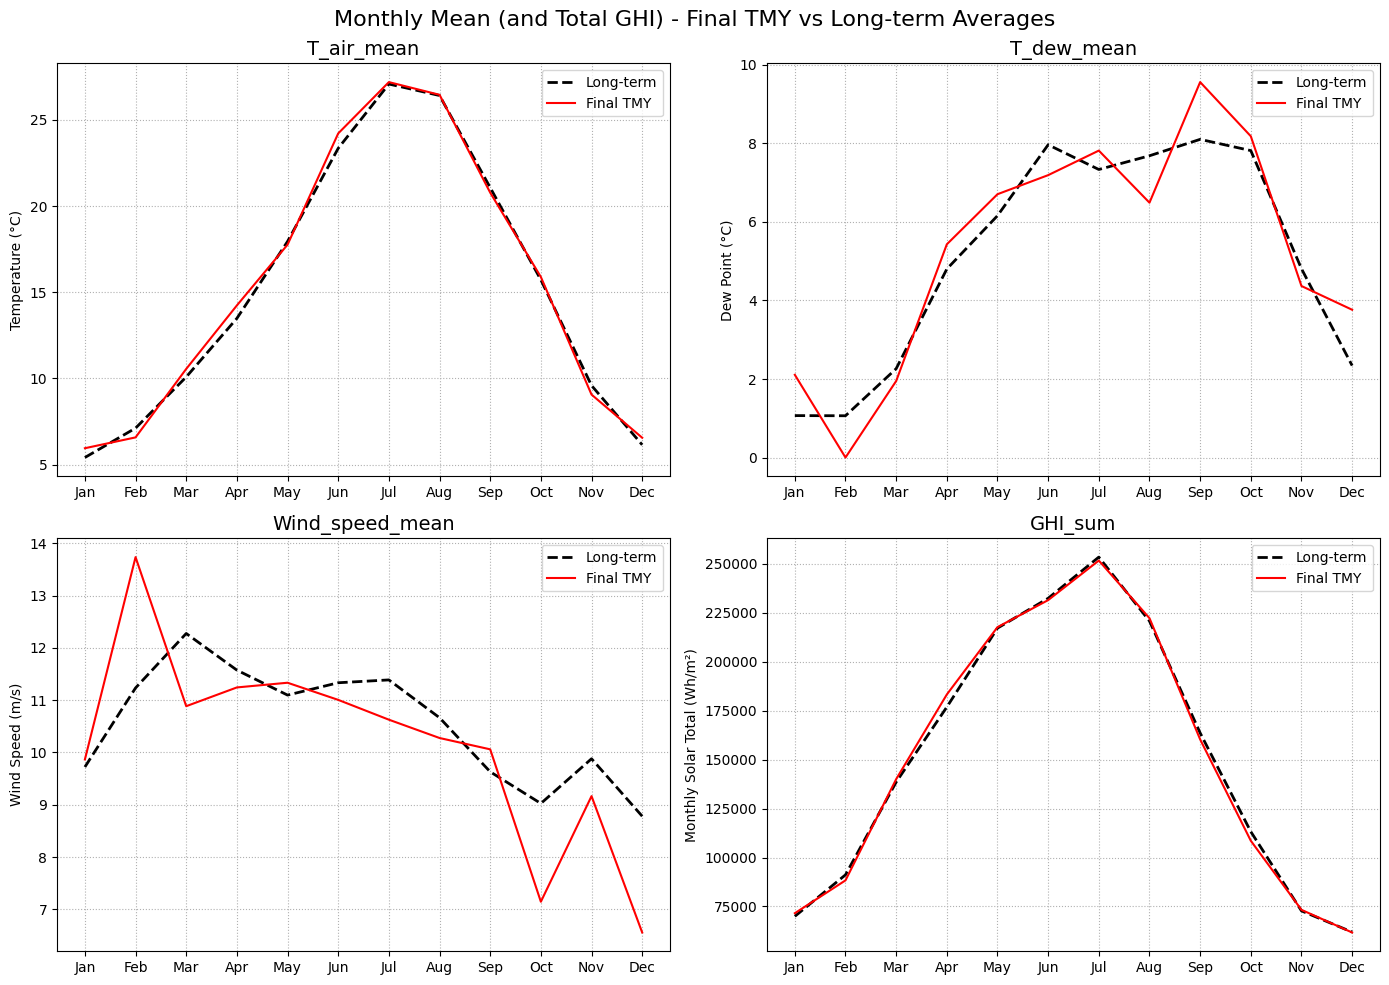

In [43]:
madrid_tmy_gen.plot_monthly_means()

In [44]:
madrid_tmy_gen.export_tmy(os.path.join(OUT_DIR, 'madrid_tmy_direct.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_tmy_direct.csv'...
Export completed successfully.


## Part 2 -- Conversion to EPW format

Every EPW file produced in this section is written by the **same** converter back-end (`HourlyEPWConverter` for the historical and typical-year scenarios, `met_epw_converter.convert_met_to_epw` for the regulatory scenario) -- the deliberate design choice discussed in Section 2.2.2 of the manuscript, which ensures that any difference observed between scenarios in a downstream simulation is attributable to climatic content rather than to format or conversion artefacts.

```{note}
Unit conventions: `HourlyEPWConverter` assumes input wind speed is in km/h (converted to m/s) and input pressure is in hPa (converted to Pa) -- the units used by the source Excel files here.
```

### Part 2.1 -- Historical scenario: multi-year hourly series to one EPW per year

`HourlyEPWConverter` is instantiated with `file_path` pointing at the raw multi-year hourly Excel file and `base_epw_path` pointing at the city's EPW template (`SEVILLE['base_epw']`), from which latitude, longitude, elevation and time zone are extracted automatically via Ladybug. The `col_*` arguments repeat the column-name mapping already used for the TMY generation in Part 1.

In [45]:
from pyweatherfiles import hourly_epw_converter

seville_hourly_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=SEVILLE['xlsx'],
    base_epw_path=SEVILLE['base_epw'],
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

In [46]:
seville_hourly_converter.available_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2021,
 2022,
 2023,
 2024,
 2025]

`process()` writes one EPW file per year found in `available_years` (unless a `years` subset is passed explicitly), naming each file according to `output_pattern`.

In [47]:
seville_hourly_converter.process(output_dir=OUT_DIR, output_pattern='seville_{year}.epw')


--- Processing year 2005 directly ---


Success! Year 2005 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2005.epw

--- Processing year 2006 directly ---


Success! Year 2006 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2006.epw

--- Processing year 2007 directly ---


Success! Year 2007 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2007.epw

--- Processing year 2008 directly ---


Success! Year 2008 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2008.epw

--- Processing year 2009 directly ---


...

Success! Year 2022 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2022.epw

--- Processing year 2023 directly ---


Success! Year 2023 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2023.epw

--- Processing year 2024 directly ---


Success! Year 2024 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2024.epw

--- Processing year 2025 directly ---


Success! Year 2025 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2025.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\HourlyEPWConverter_Seville_hourly_data_ESP_Sevilla_083910_SWEC_2005_2006_2007_2008_2009_201_b809c286.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\HourlyEPWConverter_Seville_hourly_data_ESP_Sevilla_083910_SWEC_2005_2006_2007_2008_2009_201_b809c286.json


[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2021,
 2022,
 2023,
 2024,
 2025]

We repeat the same conversion for Madrid.

In [48]:
madrid_hourly_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=MADRID['xlsx'],
    base_epw_path=MADRID['base_epw'],
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

In [49]:
madrid_hourly_converter.available_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [50]:
madrid_hourly_converter.process(output_dir=OUT_DIR, output_pattern='madrid_{year}.epw')


--- Processing year 2005 directly ---


Success! Year 2005 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2005.epw

--- Processing year 2006 directly ---


Success! Year 2006 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2006.epw

--- Processing year 2007 directly ---


Success! Year 2007 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2007.epw

--- Processing year 2008 directly ---


Success! Year 2008 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2008.epw

--- Processing year 2009 directly ---


...

Success! Year 2022 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2022.epw

--- Processing year 2023 directly ---


Success! Year 2023 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2023.epw

--- Processing year 2024 directly ---


Success! Year 2024 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2024.epw

--- Processing year 2025 directly ---


Success! Year 2025 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2025.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\HourlyEPWConverter_Madrid_hourly_data_ESP_Madrid_082210_IWEC_2005_2006_2007_2008_2009_201_24267127.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\HourlyEPWConverter_Madrid_hourly_data_ESP_Madrid_082210_IWEC_2005_2006_2007_2008_2009_201_24267127.json


[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

### Part 2.2 -- Typical-year scenario: TMY to final EPW

We reuse `HourlyEPWConverter`, this time pointing `file_path` at the TMY CSV exported in Part 1 (the single-call result: `seville_tmy_direct.csv` / `madrid_tmy_direct.csv`). Because `export_tmy()` already restored the original source column names, **no** `column_mapping` argument is needed here -- the direct payoff of that design choice, highlighted in the docstring of `export_tmy`.

In [51]:
seville_tmy_epw_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=os.path.join(OUT_DIR, 'seville_tmy_direct.csv'), base_epw_path=SEVILLE['base_epw'])

In [52]:
seville_tmy_epw_converter.process(output_dir=OUT_DIR, output_pattern='seville_tmy.epw')


--- Processing year 2000 directly ---


Success! Year 2000 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_seville_tmy_direct_ESP_Sevilla_083910_SWEC_2000_8e77da39.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_seville_tmy_direct_ESP_Sevilla_083910_SWEC_2000_8e77da39.json


[2000]

In [53]:
madrid_tmy_epw_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=os.path.join(OUT_DIR, 'madrid_tmy_direct.csv'), base_epw_path=MADRID['base_epw'])

In [54]:
madrid_tmy_epw_converter.process(output_dir=OUT_DIR, output_pattern='madrid_tmy.epw')


--- Processing year 2000 directly ---


Success! Year 2000 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_tmy.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_madrid_tmy_direct_ESP_Madrid_082210_IWEC_2000_f06fe7d9.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_madrid_tmy_direct_ESP_Madrid_082210_IWEC_2000_f06fe7d9.json


[2000]

### Part 2.3 -- Regulatory scenario: official `.met` file to EPW

`convert_met_to_epw` is a free function (no class instantiation needed). It reconstructs dew point (Magnus-formula inversion), atmospheric pressure (from absolute humidity, with the barometric formula as a physical fallback), horizontal infrared radiation (Stefan-Boltzmann inversion of the file's sky temperature) and direct normal irradiance (from the direct horizontal component using exact solar geometry, capped at the solar constant). `replace_unused_with_missing=True` fills the 15 EPW fields that EnergyPlus does not use with the format's official missing-value codes rather than zeros. A radiation-balance quality-control check is printed automatically for every conversion.

In [55]:
from pyweatherfiles import met_epw_converter

seville_met_success = met_epw_converter.convert_met_to_epw(
    met_path=SEVILLE['met'],
    base_epw_path=SEVILLE['base_epw'],
    epw_path=os.path.join(OUT_DIR, 'seville_met.epw'),
    replace_unused_with_missing=True,
)

Starting conversion of 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\seville.met' to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_met.epw'...


  - Recalculating zenith angle (theta_z) and balancing radiation...
  - QA DNI -> min=0.0, p95=897.2, max=1367.0 W/m2 | low_sun=4630, clipped=13, negative_dir_horiz=0
  - QA balance (GHI - (DHI + DNI*cos(theta_z))) -> abs_mean=0.16 W/m2, abs_p95=0.00 W/m2


MET -> EPW conversion completed (radiation balance ensured)!
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_seville_seville_met_ESP_Sevilla_083910_SWEC_d9015128.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_seville_seville_met_ESP_Sevilla_083910_SWEC_d9015128.json


In [56]:
madrid_met_success = met_epw_converter.convert_met_to_epw(
    met_path=MADRID['met'],
    base_epw_path=MADRID['base_epw'],
    epw_path=os.path.join(OUT_DIR, 'madrid_met.epw'),
    replace_unused_with_missing=True,
)

Starting conversion of 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\madrid.met' to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_met.epw'...


  - Recalculating zenith angle (theta_z) and balancing radiation...


  - QA DNI -> min=0.0, p95=865.3, max=1367.0 W/m2 | low_sun=4701, clipped=7, negative_dir_horiz=0
  - QA balance (GHI - (DHI + DNI*cos(theta_z))) -> abs_mean=0.03 W/m2, abs_p95=0.00 W/m2


MET -> EPW conversion completed (radiation balance ensured)!
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_madrid_madrid_met_ESP_Madrid_082210_IWEC_02b45438.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_madrid_madrid_met_ESP_Madrid_082210_IWEC_02b45438.json


## Part 3 -- Degree-hours and climate-trend analysis

This section reproduces Section 3.1 of the manuscript ('The climate in Spain: evolution and trend') -- restricted here to the two case-study cities -- using the annual historical EPW files generated in Part 2.1. Three degree-hour indicators are computed for every available year:

1. **Heating degree-hours** (HDH20), base temperature 20 °C, over the full day: the hourly sum of `max(0, 20 - T)`.
2. **Cooling degree-hours** (CDH25), base temperature 25 °C, over the full day: the hourly sum of `max(0, T - 25)`.
3. **Night cooling potential** (NCDH25): the hourly sum of `max(0, 25 - T)` restricted to the 00:00-08:00 window (inclusive) and to the summer months July to September.

```{important}
NCDH is a **cooling potential**, not an overheating indicator. It accumulates the degrees that are still *missing* to reach the 25 °C base (`max(0, 25 - T)`) -- i.e. how much cool outdoor air passive night ventilation can still draw on -- and not the excess above it (`max(0, T - 25)`, which is the classic cooling degree-hour of indicator 2). It is obtained by passing `invert_cooling=True` to the scenario, which flips that formula, together with `months=[7, 8, 9]` to restrict it to the summer.

Because of this sign convention, its trend reads the opposite way to CDH25: a **decreasing** NCDH25 means warmer nights and therefore *less* passive night-cooling potential.
```

`pyweatherfiles.degree_hours.EpwGroupTrendAnalyzer` is the class designed for exactly this 'many years, several independent climates, never pooled' analysis. Here we exercise it over Seville and Madrid; pointing it at a folder containing more `<city>_<year>.epw` files is all it takes to reproduce the manuscript's full five-city version.

### Part 3.1 -- A single-file warm-up (`DegreeHoursCalculator`)

Before scaling up to the full multi-year batch, we introduce `DegreeHoursCalculator` on a single EPW: one representative historical year of Seville. `setpoint_source` is a plain configuration dictionary (`type='constant'`) rather than an IDF path -- the lightweight alternative for climate-only analyses that do not need a full building model.

In [57]:
from pyweatherfiles.degree_hours import DegreeHoursCalculator, EpwGroupTrendAnalyzer

demo_year = seville_hourly_converter.available_years[0]
demo_calc = DegreeHoursCalculator(epw_path=os.path.join(OUT_DIR, f'seville_{demo_year}.epw'))

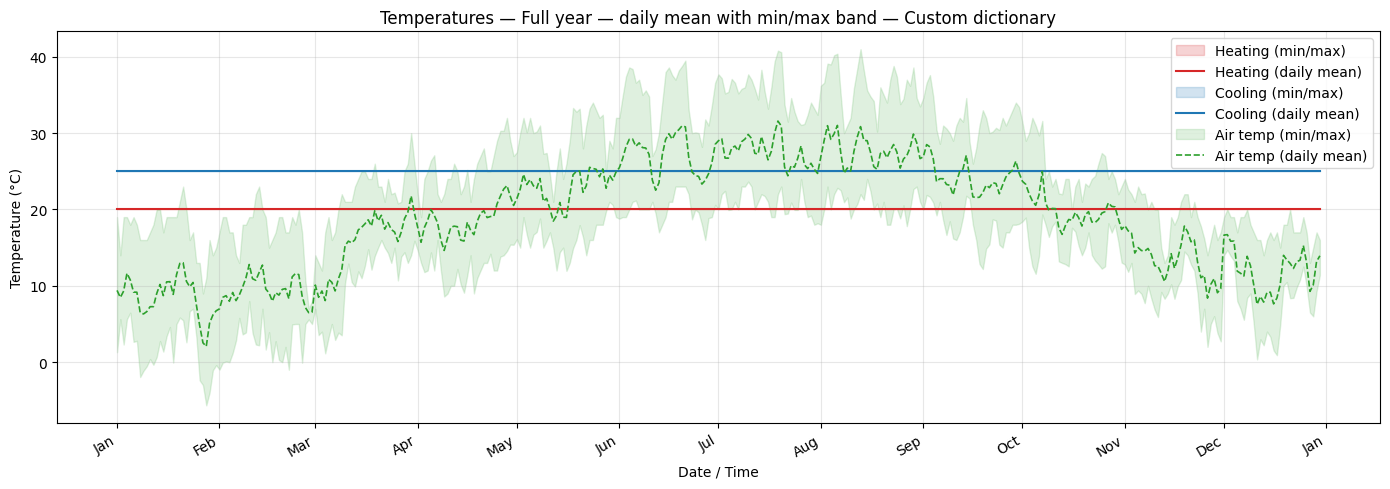

In [58]:
demo_calc.plot(setpoint_source={'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
               period='year', show_air_temp=True)

In [59]:
demo_results = demo_calc.calculate({'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
                                    frequency=['yearly'], mode='both', save_session=False)

[INFO] Calculating degree-hours (mode='both', hours=all, months=all, invert_cooling=False)…
[INFO] Calculation completed.
  yearly: (1, 2) -> {'heating_dh': 34755.20280992029, 'cooling_dh': 10860.27026349748}


In [60]:
demo_results['yearly']

,heating_dh,cooling_dh
2000-12-31,34755.20281,10860.270263


### Part 3.2 -- Multi-year batch analysis across both cities

`EpwGroupTrendAnalyzer(epw_dir=...)` scans the Part 2.1 output folder for files matching `filename_pattern` (default `<group>_<year>.epw`, matching the `output_pattern` used above), classifying them into `{city: {year: path}}`. `setpoint_source` is the same constant 20/25 °C configuration used in the manuscript, and `hours_scenarios` defines the degree-hour scenarios to compute for every file:

- `'allday'` -- all 24 hours of every day, both modes, producing the `heating_dh_allday` and `cooling_dh_allday` columns.
- `'night_potential_jul_sep'` -- the night-cooling potential described above, producing `cooling_dh_night_potential_jul_sep`: `hours=list(range(0, 9))` (00:00 to 08:00 inclusive, i.e. 9 hourly values), `months=[7, 8, 9]` (July to September), `mode='cooling'` and `invert_cooling=True`, which turns the cooling formula into `max(0, 25 - T)`.

`group_labels`/`group_colors` only affect the display of the two cities in later plots.

In [61]:
HOURS_SCENARIOS = {
    'allday': {'hours': None, 'mode': 'both'},
    'night_potential_jul_sep': {
        'hours': list(range(0, 9)),      # 00:00-08:00 inclusive (9 hourly values)
        'mode': 'cooling',
        'invert_cooling': True,          # degrees MISSING to reach 25 degC (potential), not excess above it
        'months': [7, 8, 9],   # restricted to summer months (Jul-Sep)
    },
}

trend_analyzer = EpwGroupTrendAnalyzer(epw_dir=OUT_DIR,
    setpoint_source={'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
    hours_scenarios=HOURS_SCENARIOS,
    group_labels={'seville': 'Seville', 'madrid': 'Madrid'})

[WARNING] Filename does not match filename_pattern, skipping: madrid_met.epw
[WARNING] Filename does not match filename_pattern, skipping: madrid_tmy.epw
[WARNING] Filename does not match filename_pattern, skipping: seville_met.epw
[WARNING] Filename does not match filename_pattern, skipping: seville_tmy.epw
[INFO] Classified 41 EPW file(s) into 2 group(s): ['madrid', 'seville']


In [62]:
trend_analyzer.file_groups

{'madrid': {2005: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2005.epw',
  2006: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2006.epw',
  2007: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2007.epw',
  2008: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2008.epw',
  2009: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2009.epw',
  2010: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2010.epw',
  2011: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2011.epw',
  2012: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2012.epw',
  2013: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2013.epw',
  2014: 'D:\\Python\\pyweat

In [63]:
results_df = trend_analyzer.run()

[OK] madrid       2005 -> heating_dh_allday=63836.6, cooling_dh_allday=7891.1, cooling_dh_night_potential_jul_sep=5071.2


[OK] madrid       2006 -> heating_dh_allday=56817.7, cooling_dh_allday=8539.6, cooling_dh_night_potential_jul_sep=4604.7


[OK] madrid       2007 -> heating_dh_allday=63714.9, cooling_dh_allday=5209.6, cooling_dh_night_potential_jul_sep=5588.0


[OK] madrid       2008 -> heating_dh_allday=62379.6, cooling_dh_allday=6321.0, cooling_dh_night_potential_jul_sep=5580.3


[OK] madrid       2009 -> heating_dh_allday=57473.0, cooling_dh_allday=8861.6, cooling_dh_night_potential_jul_sep=4312.5


...

[OK] seville      2022 -> heating_dh_allday=30250.8, cooling_dh_allday=12848.6, cooling_dh_night_potential_jul_sep=2526.6


[OK] seville      2023 -> heating_dh_allday=31992.9, cooling_dh_allday=13440.4, cooling_dh_night_potential_jul_sep=2468.1


[OK] seville      2024 -> heating_dh_allday=30811.7, cooling_dh_allday=10009.1, cooling_dh_night_potential_jul_sep=2811.5


[OK] seville      2025 -> heating_dh_allday=30046.1, cooling_dh_allday=15613.7, cooling_dh_night_potential_jul_sep=1987.6

[INFO] EpwGroupTrendAnalyzer.run() completed: 41 group-year rows.


[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\EpwGroupTrendAnalyzer_case_study_output_2_41_5043b61b.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\EpwGroupTrendAnalyzer_case_study_output_2_41_5043b61b.json


In [64]:
results_df

,group,year,heating_dh_allday,cooling_dh_allday,cooling_dh_night_potential_jul_sep
0,madrid,2005,63836.596127,7891.131553,5071.197718
1,madrid,2006,56817.718541,8539.579740,4604.700000
2,madrid,2007,63714.904655,5209.566758,5588.002353
3,madrid,2008,62379.585172,6321.000000,5580.300000
4,madrid,2009,57473.024665,8861.556915,4312.500000
5,madrid,2010,65187.462866,6406.300000,4729.069998
6,madrid,2011,58331.361699,6547.202067,5386.468343
7,madrid,2012,63931.163157,7554.440015,5206.583303
8,madrid,2013,64404.489890,7324.264333,4449.300000
9,madrid,2014,52275.996457,6335.597150,4754.300000


### Part 3.3 -- Per-city and global trend statistics

`compute_trends(value_col)` fits an independent OLS year-over-year trend per city (never pooled). `fit_global_trend(value_col)` instead fits a **global fixed-effects** model, `value ~ year + C(city)`, sharing the exact estimator used by `EpwTrendAnalyzer.fit_global_model()` (see `pyweatherfiles.trend_stats`) -- the same technique behind the manuscript's pooled/balanced-panel warming-rate estimates in Section 3.1.

Mind the sign convention of each indicator when reading the slopes: a warming climate produces a **negative** slope for `heating_dh_allday` (less heating demand), a **positive** one for `cooling_dh_allday` (more cooling demand) and, again, a **negative** one for `cooling_dh_night_potential_jul_sep` -- warmer summer nights leave fewer degrees below the 25 °C base, so the passive night-cooling potential shrinks.

In [65]:
trend_analyzer.compute_trends('heating_dh_allday')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,-328.015093,719961.800183,0.283960,0.012875,True
seville,20,-61.412626,156147.252641,0.027869,0.481761,False


In [66]:
trend_analyzer.compute_trends('cooling_dh_allday')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,104.914024,-203588.663951,0.259751,0.018271,True
seville,20,124.879702,-240419.716654,0.177972,0.063919,False


In [67]:
trend_analyzer.compute_trends('cooling_dh_night_potential_jul_sep')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,-46.43009,98244.332324,0.308713,0.008922,True
seville,20,-6.96853,16716.218680,0.010010,0.674711,False


In [68]:
global_night_trend = trend_analyzer.fit_global_trend('cooling_dh_night_potential_jul_sep')

In [69]:
global_night_trend

FixedEffectResult(target='cooling_dh_night_potential_jul_sep', slope_c_per_year=-27.041462027998328, intercept=59176.247020505056, std_error=11.702751104220837, t_stat=-2.3106927411491536, p_value=0.026372610092309623, ci95_low=-50.73244306509734, ci95_high=-3.3504809908993103, r2=0.843771711725964, n_obs=41, n_cities=2, df_resid=38)

### Part 3.4 -- Trend figure

`plot_overview_grid` is the library's native view of `results_df`: one panel per indicator and per city, each showing that city's own year-by-year bars together with its OLS trend line (cities are never pooled). The `variables` argument takes one `(column, y-axis label, panel title)` tuple per indicator, and `transpose=True` lays the grid out with one column per city.

The three panels of each city illustrate the sign conventions discussed above: HDH20 decreases, CDH25 increases, and NCDH25 also decreases -- the last one meaning *less* cool night air available for passive ventilation, not less overheating.

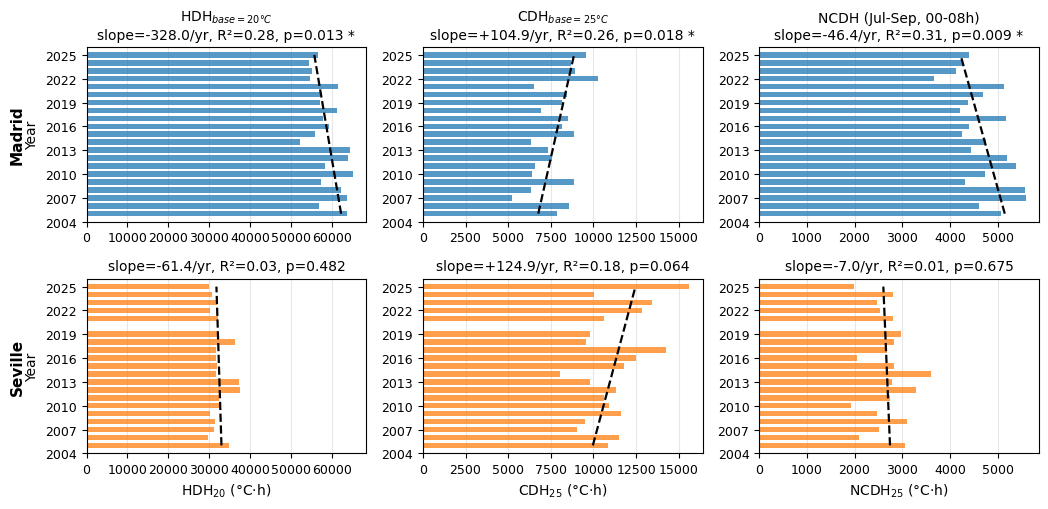

In [70]:
fig_overview = trend_analyzer.plot_overview_grid(
        variables=[
            ('heating_dh_allday', 'HDH$_{20}$ (°C·h)', 'HDH$_{base=20°C}$'),
            ('cooling_dh_allday', 'CDH$_{25}$ (°C·h)', 'CDH$_{base=25°C}$'),
            ('cooling_dh_night_potential_jul_sep', 'NCDH$_{25}$ (°C·h)', 'NCDH (Jul-Sep, 00-08h)'),
        ],
        horizontal=True,
        transpose=True,
        show=True,
        # out_path='fig3_overview_grid_by_city.png',
    )

### Part 3.5 -- Exporting the results

`export_results` writes `results_df` (one sheet) plus every cached `compute_trends` table (one sheet each) to a single Excel workbook when the output path ends in `.xlsx`.

In [71]:
export_path = trend_analyzer.export_results(os.path.join(OUT_DIR, 'seville_madrid_climate_trend.xlsx'))

[INFO] Results exported to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_madrid_climate_trend.xlsx


## Part 4 -- Conclusions and further reading

This notebook demonstrated, on real data for two Spanish provincial capitals:

- The complete seven-step Sandia/TMY3 generation pipeline, both as an auditable step-by-step sequence and as a single convenience call, with the two approaches cross-checked against each other.
- The conversion of all three climate scenarios of the manuscript's simulation battery -- historical, typical-year and regulatory -- into a common EPW format via the same converter back-end.
- The degree-hour and climate-trend analysis of Section 3.1 of the manuscript, including the night-cooling-potential indicator and the exact global fixed-effects trend estimator shared with `EpwTrendAnalyzer`, restricted here to the two case-study cities.

```{tip}
Part 3 scales to any number of locations: point `EpwGroupTrendAnalyzer` at a folder holding more `<city>_<year>.epw` files and the very same code reproduces the manuscript's full five-city version. For the complete API reference of every class and method used above, see the documentation site or, equivalently, `README.md` / `README_ES.md`.
```

```{note}
Every main step of Part 1 and every converter call in Parts 2-3 either writes or intentionally skips (`save_session=False`) a reproducible `.pkl`/`.json` session snapshot next to its input/output file, recording the exact parameters used -- see `pyweatherfiles.session_manager` and Section 2.2.2 of the manuscript.
```